# Práctica entregable: Segmentación de imaxes con Deep Learning

-----
Notas importantes para a entrega: teredes que entregar un arquivo comprimido en formato .zip co formato `Apelidos_Nome_P5.zip` (sen acentos nin caracteres especiais, p.ex., PerezGarcia_Juan_P5.zip), que conterá dous arquivos.
- Este Jupyter Notebook cos exercicios resoltos e todas as celdas executadas (de tal maneira que se poidan ver os resultados), que terá o nome `Apelidos_Nome_P5.ipynb`
- O mesmo notebook exportado a HTML, co nome `Apelidos_Nome_P5.html`. Do mesmo xeito, deberedes ter todas as celdas executadas antes de exportalo, para que se poidan ver os resultados.
-----

Nesta práctica imos traballar directamente con modelos de Deep Learning orientados á segmentación de imaxes, utilizando distintas arquitecturas do estado da arte. Dado que o adestramento destes sistemas pode ser computacionalmente intensivo, recoméndase empregar Google Colab ou, de non ser suficiente, o clúster de computación do CESGA.

O conxunto de datos que empregaremos será de novo o *FruitSeg30*, que xa utilizamos na práctica anterior. Se non o fixeches, descarga e descomprime dito conxunto executando a celda seguinte:

In [10]:
from pathlib import Path
import zipfile
from urllib import request

import torch
from torch import nn
from torchvision.transforms import functional as TF
import torch.optim as optim
from torchvision.models.segmentation import fcn_resnet50, deeplabv3_resnet50
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import directed_hausdorff

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torchvision.transforms as T


In [11]:
url = 'https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/vkht8pfsp3-3.zip'
dataset_name = Path('FruitSeg30_Segmentation Dataset & Mask Annotations')
output_zip_path = Path('FruitSeg30.zip')
dataset_dir = Path('FruitSeg30')

if not dataset_dir.is_dir():
    request.urlretrieve(url, output_zip_path)
    with zipfile.ZipFile(output_zip_path, 'r') as zip_ref:
        zip_ref.extractall()

    (dataset_name/dataset_dir).rename(dataset_dir)

    output_zip_path.unlink()
    dataset_name.rmdir()

In [12]:
!git clone https://github.com/mateofra/VPC_

Cloning into 'VPC_'...
remote: Enumerating objects: 4256, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 4256 (delta 9), reused 10 (delta 4), pack-reused 4238 (from 1)
Receiving objects: 100% (4256/4256), 553.56 MiB | 16.06 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Updating files: 100% (4245/4245), done.


In [13]:
%cd VPC_/Practicassss

/content/VPC_/Practicassss/VPC_/Practicassss


## Arquitectura U-Net

A rede U-Net é unha arquitectura de rede neuronal convolucional deseñada para tarefas de segmentación de imaxes, inicialmente desenvolvida para segmentación biomédica. A súa estrutura ten forma de "U", estando composta por unha parte de contracción (encoder) e unha parte de expansión (decoder). Debaixo podes ver un esquema da arquitectura orixinal proposta no 2015 por Olaf Ronneberger et al. no artigo ["U-Net: Convolutional Networks for Biomedical Image Segmentation"](https://arxiv.org/abs/1505.04597).

<center>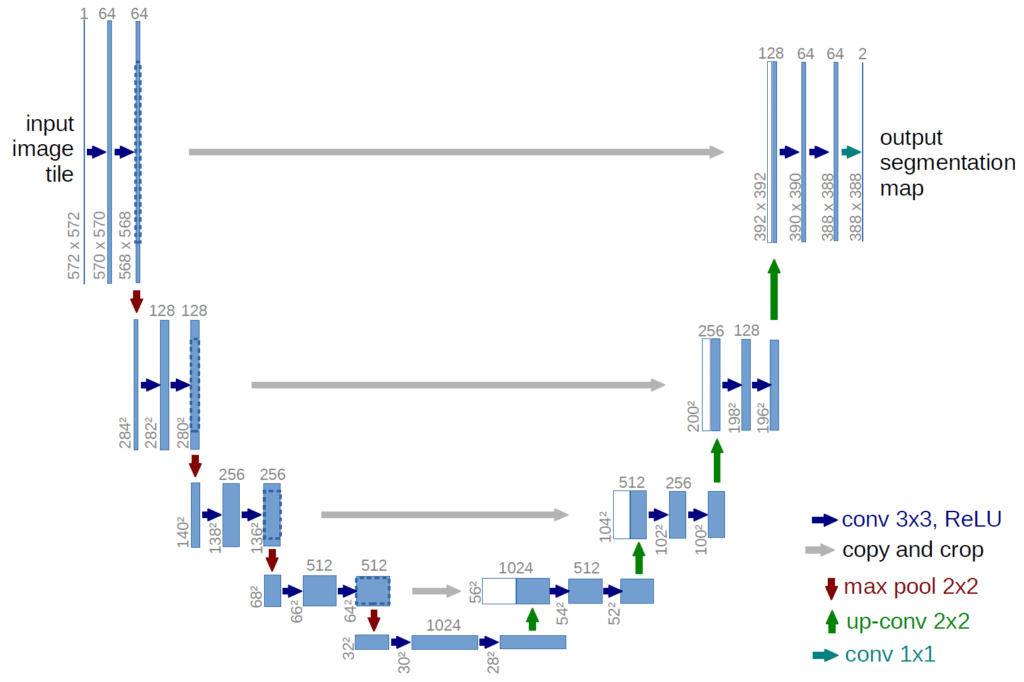</center>

A parte do codificador segue unha estrutura convencional de rede neuronal convolucional (CNN) para extraer características relevantes das imaxes de entrada. A imaxe de entrada é procesada en bloques, onde se lle aplican dúas capas convolucionais seguidas dunha capa de *pooling* para reducir a dimensión espacial das características extraídas. Cada capa convolucional utiliza un tamaño de filtro de 3x3 e unha función de activación ReLU para introducir non linealidade no modelo. A capa de *pooling* emprega unha operación de max-pooling con un tamaño de 2x2 para reducir a resolución das características, o que axuda a diminuír o número de parámetros e a evitar o sobreaxuste. Ao igual que nunha CNN básica, o número de filtros nas capas convolucionais duplícase por dous despois de cada capa de *pooling*, permitindo á rede capturar características máis complexas a medida que avanza.

A parte do decodificador segue unha estrutura simétrica á do codificador. As características obtidas do codificador son procesadas en bloques, onde se lle aplican un *upsampling* para aumentar a resolución seguido de dúas capas convolucionais. Cada capa convolucional tamén utiliza un tamaño de filtro de 3x3 e unha función de activación ReLU. Dependendo da implementación, as capa de *upsampling* consisten nunha operación de reescalado sinxela (utilizando interpolación) ou unha convolución trasposta. Neste caso, o número de filtros nas capas convolucionais do decodificador redúcese á metade despois de cada operación de *upsampling*, restaurando gradualmente a resolución orixinal da imaxe de entrada.

É tamén relevante que en cada nivel de profundidade da rede, as características do codificador son concatenadas coas características correspondentes do decodificador. Esta técnica, coñecida como "skip connections" ou conexións de salto, axuda a preservar a información espacial e os detalles finos da imaxe orixinal, facilitando unha mellor reconstrucción da imaxe de saída.


A continuación amósase un exemplo de código en Pytorch que implementa esta arquitectura:

In [14]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        # Encoder
        for feature in features:
            self.encoder.append(self.conv_block(in_channels, feature))
            in_channels = feature
        # Decoder
        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(self.conv_block(feature*2, feature))
        self.bottleneck = self.conv_block(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        skip_connections = []
        for layer in self.encoder:
            x = layer(x)
            skip_connections.append(x)
            x = nn.MaxPool2d(kernel_size=2)(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            x = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx+1](x)
        return self.final_conv(x)

## Exercicio proposto

1. Crea un dataset xenérico (mediante unha clase que herde de `torch.utils.data.Dataset`). O constructor debe recibr como parámetro os directorios das imaxes e das máscaras, por exemplo `FruitSeg30/Apple_Gala/Images` e `FruitSeg30/Apple_Gala/Mask`. Este clase debe implementar ademáis os métodos `__len__` e `__getitem__`, de xeito que o primeiro devolva o número de imaxes no conxunto de datos, e o segundo devolva unha tupla `(imaxe, máscara)` para o índice dado. Para cargar as imaxes e máscaras, podes empregar a biblioteca `PIL`. Logo de cargar a imaxe e a máscara, aplícalles as transformacións necesarias para devolvelas como obxectos da clase `torch.Tensor` e cun tamaño de 128x128.
2. Crea os obxectos `Dataset` e `DataLoader` necesarios para cargar o conxunto de datos de imaxes e máscaras de segmentación. Deberás obter un dicionario no que as chaves sexan as categorías (`Apple_Gala`, `Apple_Golden Delicious`, etc.), e os valores sexan á súa vez dicionarios cuxas chaves serán `dataset_train`, `dataset_val`, `dataset_test`,  `dataloader_train`, `dataloader_val` e `dataloader_test`. Utiliza un tamaño de lote de 4 para o `Dataloader` de adestramento (os de validación e test poden levar calquera tamaño de lote) e un split aleatorio de 60%/20%/20% para a división entre conxuntos de adestramento, validación e test.

    Exemplo:

    ```python
    {
        'Apple_Gala': {
            'dataset_train': <Dataset object>,
            'dataset_val': <Dataset object>,
            'dataset_test': <Dataset object>,
            'dataloader_train': <DataLoader object>,
            'dataloader_val': <DataLoader object>,
            'dataloader_test': <DataLoader object>,
        },
        'Apple_Golden Delicious': {
            ...
        },
        ...
    }
    ```

3. Proba os modelos de segmentación DeepLabV3 e FCN, do paquete `torchvision.models.segmentation`, e a implementación da UNet proposta nesta práctica. Ten en conta o seguinte:
- Utiliza os `DataLoader` creados no exercicio anterior para adestrar e validar os modelos.
- Emprega como función de perda a entropía cruzada binaria, e como optimizador `Adam`.
- Adestra os modelos utilizando *early stopping* para evitar o sobreaxuste, é dicir, para o adestramento cando a perda obtida no conxunto de validación non mellore durante un número determinado de épocas. Quédate co modelo que obteña a mellor perda no conxunto de validación.
- Obtén as métricas Dice e Hausdorff no conxunto de test para cada modelo e cada categoría (se o adestramento consume moito tempo podes seleccionar un subconxunto de categorías, como mínimo 3). Compara os resultados obtidos cos distintos modelos, incluíndo na comparativa o número de parámetros de cada modelo.
- Xera visualizacións dos resultados obtidos. Para cada modelo e categoría, amosa o resultado da segmentación no mellor e no peor caso, utilizando a visualización TP, TN, FP e FN que se explicou na práctica anterior.
- Xustifica se as predicións se poderían mellorar empregando operacións morfolóxicas de postprocesado.
4. Contesta ás seguintes preguntas sobre a arquitectura `UNet`:
- Que cambios habería que facer na implementación da UNet para aumentar o número de niveis de profundidade?
- Poderíamos aumentar indefinidamente o número de niveis de profundidade da UNet ou existe algunha limitación?
- Se aumentamos o tamaño das imaxes de entrada, seguiría funcionando a implementación actual da UNet?

## Apartado 1

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, masks_dir, size=128):
        
        self.transform_img = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),
        ])
        self.transform_mask = T.Compose([
            T.Resize((size, size), interpolation=Image.NEAREST),
            T.ToTensor(),
        ])

        self.pares = []
        imaxes = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg'))])

        for nome in imaxes:
            localizacion_img = os.path.join(img_dir, nome)

            # Separamos el nombre del archivo de su extensión (ej: '1', '.jpg')
            parte_nome, _ = os.path.splitext(nome)
            # Construimos el nombre correcto de la máscara (ej: '1_mask.png')
            mask_nome = parte_nome + '_mask.png'

            localizacion_mask = os.path.join(masks_dir, mask_nome)

            if os.path.exists(localizacion_mask):
                self.pares.append((localizacion_img, localizacion_mask))

    def __len__(self):
        return len(self.pares)

    def __getitem__(self, idx):
        img_path, mask_path = self.pares[idx]
        imagen = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')
        imagen = self.transform_img(imagen)
        mask = self.transform_mask(mask)
        mask = (mask > 0.5).float()
        return imagen, mask

## Apartado 2

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

directorios = [d.name for d in dataset_dir.iterdir() if d.is_dir()]
data_dicc = {}

for dir in directorios:
    img_dir = dataset_dir / dir / 'Images'
    mask_dir = dataset_dir / dir / 'Mask'

    full_dataset = SegmentationDataset(img_dir, mask_dir)
    #índices
    idxs = list(range(len(full_dataset)))

    # indices dos subsets
    train_idx, temp_idx = train_test_split(idxs, test_size=0.4, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

    # creamos los subsets
    ds_train = Subset(full_dataset, train_idx)
    ds_val = Subset(full_dataset, val_idx)
    ds_test = Subset(full_dataset, test_idx)

    # 5. Crear los DataLoaders como antes
    data_dicc[dir] = {
        'dataset_train': ds_train,
        'dataset_val': ds_val,
        'dataset_test': ds_test,
        'dataloader_train': DataLoader(ds_train, batch_size=4, shuffle=True, drop_last=True),
        'dataloader_val': DataLoader(ds_val, batch_size=8, shuffle=False),
        'dataloader_test': DataLoader(ds_test, batch_size=8, shuffle=False),
    }

## Apartado 3

In [ ]:
#  Funciones para Métricas
# 2*|X interseccion Y| / (|X| + |Y|)
def dice_coefficient(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred) > 0.5
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    intersection = (pred_flat * target_flat).sum()
    dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
    return dice.item()

# max{sup d(x,Y), sup d(X,y)}
def hausdorff_distance(pred, target):
    pred_coords = np.transpose(np.nonzero(pred.squeeze().cpu().numpy()))
    target_coords = np.transpose(np.nonzero(target.squeeze().cpu().numpy()))

    # La distancia de Hausdorff no está definida si un conjunto está vacío
    if len(pred_coords) == 0 or len(target_coords) == 0:
        return float('inf') # O un valor alto predefinido

    # Calcular la distancia de Hausdorff dirigida en ambas direcciones y tomar el máximo
    h1 = directed_hausdorff(pred_coords, target_coords)[0]
    h2 = directed_hausdorff(target_coords, pred_coords)[0]
    return max(h1, h2)


#  Función de adestramento e validacion con Early Stopping

def adestrar_modelo(modelo, dataloaders, criterion, optimizer, device, num_epocas=25, patience=5):

    modelo.to(device)
    mellor_perdida_validacion = float('inf')
    paciencia = 0
    mellor_estado = None

    for epoca in range(num_epocas):

        # Fase de entrenamiento
        modelo.train()
        perdida_adestramento = 0.0

        for inputs, masks in dataloaders['dataloader_train']:

            inputs, masks = inputs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = modelo(inputs)
            # torchvision devolven un dict, a UNet non
            # se outputs é un dict, obtemos 'out'
            if isinstance(outputs, dict):
                outputs = outputs['out']

            perdida = criterion(outputs, masks)
            perdida.backward()
            optimizer.step()
            perdida_adestramento += perdida.item() * inputs.size(0)

        perdida_epoca = perdida_adestramento / len(dataloaders['dataset_train'])

        # Fase de validación
        modelo.eval()
        perdida_validacion = 0.0
        with torch.no_grad():
            for inputs, masks in dataloaders['dataloader_val']:
                inputs, masks = inputs.to(device), masks.to(device)
                outputs = modelo(inputs)
                if isinstance(outputs, dict):
                    outputs = outputs['out']
                loss = criterion(outputs, masks)
                perdida_validacion += loss.item() * inputs.size(0)

        perdida_validacion /= len(dataloaders['dataset_val'])
        print(f'Época {epoca+1}/{num_epocas}, Pérdida {perdida_epoca:.4f}, Pérdida Validación: {perdida_validacion:.4f}')

        # Lóxica de Early Stopping
        if perdida_validacion < mellor_perdida_validacion:
            mellor_perdida_validacion = perdida_validacion
            paciencia = 0
            mellor_estado = modelo.state_dict()
        else:
            paciencia += 1
            if paciencia >= patience:
                print(f'Early stopping na época {epoca+1}')
                break

    #  mellor modelo
    modelo.load_state_dict(mellor_estado)
    return modelo

#  Función de avaliacion en el conjunto de Test

def avaliar_modelo(modelo, dataloader_test, device):
    modelo.eval()
    modelo.to(device)
    metrica_dice = []
    metrica_hausdorff = []

    mellor_caso = {'score': -1, 'data': None}
    peor_caso = {'score': 2, 'data': None} # Dice va de 0 a 1

    with torch.no_grad():
        for inputs, masks in dataloader_test:
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = modelo(inputs)
            if isinstance(outputs, dict):
                outputs = outputs['out']

            # Iterar sobre cada imaxe
            for j in range(inputs.size(0)):

                pred = torch.sigmoid(outputs[j]) > 0.5
                mask = masks[j]

                #cálcul das métricas
                dice = dice_coefficient(outputs[j], mask)
                hd = hausdorff_distance(pred, mask)

                metrica_dice.append(dice)
                if hd != float('inf'): #só distancias válidas!!
                    metrica_hausdorff.append(hd)

                # Gardar casos (basados en Dice)
                if dice > mellor_caso['score']:
                    mellor_caso['score'] = dice
                    mellor_caso['data'] = (inputs[j].cpu(), mask.cpu(), pred.cpu())
                if dice < peor_caso['score']:
                    peor_caso['score'] = dice
                    peor_caso['data'] = (inputs[j].cpu(), mask.cpu(), pred.cpu())

    dice_promedio = np.mean(metrica_dice)
    hd_promedio = np.mean(metrica_hausdorff) if metrica_hausdorff else float('nan')

    return dice_promedio, hd_promedio, mellor_caso, peor_caso

#  Función de Visualización
def resultados(imaxe, true_mask, pred_mask, titulo):
    true_mask = true_mask.squeeze().numpy()
    pred_mask = pred_mask.squeeze().numpy()

    # Calcular TP, FP e FN
    tp = np.logical_and(true_mask, pred_mask)
    fp = np.logical_and(np.logical_not(true_mask), pred_mask)
    fn = np.logical_and(true_mask, np.logical_not(pred_mask))

    #  imaxen de visualización
    overlay = np.zeros((imaxe.shape[1], imaxe.shape[2], 3), dtype=np.uint8)
    overlay[tp] = [255, 255, 255]  # Blanco
    overlay[fp] = [255, 0, 0]    # Vermello
    overlay[fn] = [0, 0, 255]    # Azul ¡

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(titulo, fontsize=16)

    axes[0].imshow(imaxe.permute(1, 2, 0))
    axes[0].set_title("Imagen Original")
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title("Máscara Real ")
    axes[1].axis('off')

    axes[2].imshow(pred_mask, cmap='gray')
    axes[2].set_title("Máscara Modelada")
    axes[2].axis('off')

    axes[3].imshow(overlay)
    axes[3].set_title("Visualización (TP: Blanco, FP: Vermello, FN: Azul)")
    axes[3].axis('off')

    plt.show()

Executando na cuda
 Adestrando en : Apple_Gala 

 Entrenando modelo: UNet 
Época 1/30, Pérdida 0.6538, Pérdida Validación: 0.6956
Época 2/30, Pérdida 0.6307, Pérdida Validación: 0.6590
Época 3/30, Pérdida 0.5578, Pérdida Validación: 0.5525
Época 4/30, Pérdida 0.4227, Pérdida Validación: 0.4127
Época 5/30, Pérdida 0.2775, Pérdida Validación: 0.2652
Época 6/30, Pérdida 0.1925, Pérdida Validación: 0.2190
Época 7/30, Pérdida 0.1641, Pérdida Validación: 0.2059
Época 8/30, Pérdida 0.1392, Pérdida Validación: 0.1556
Época 9/30, Pérdida 0.0785, Pérdida Validación: 0.0685
Época 10/30, Pérdida 0.0405, Pérdida Validación: 0.0446
Época 11/30, Pérdida 0.0299, Pérdida Validación: 0.0315
Época 12/30, Pérdida 0.0242, Pérdida Validación: 0.0309
Época 13/30, Pérdida 0.0232, Pérdida Validación: 0.0279
Época 14/30, Pérdida 0.0218, Pérdida Validación: 0.0278
Época 15/30, Pérdida 0.0216, Pérdida Validación: 0.0254
Época 16/30, Pérdida 0.0185, Pérdida Validación: 0.0229
Época 17/30, Pérdida 0.0178, Pérdida V

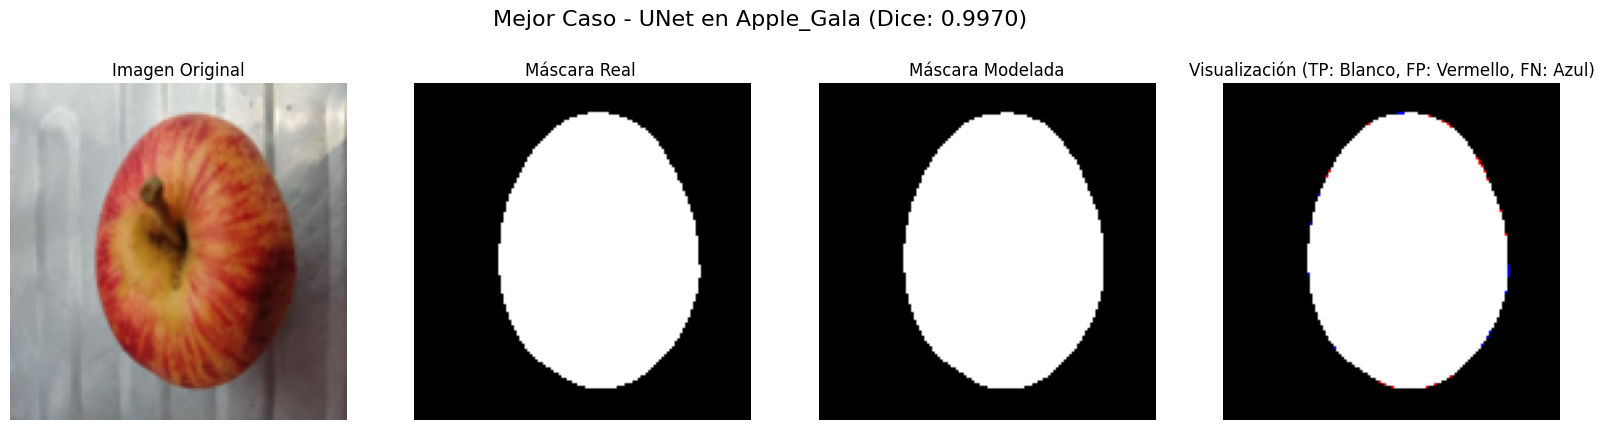


Visualizando peor caso...


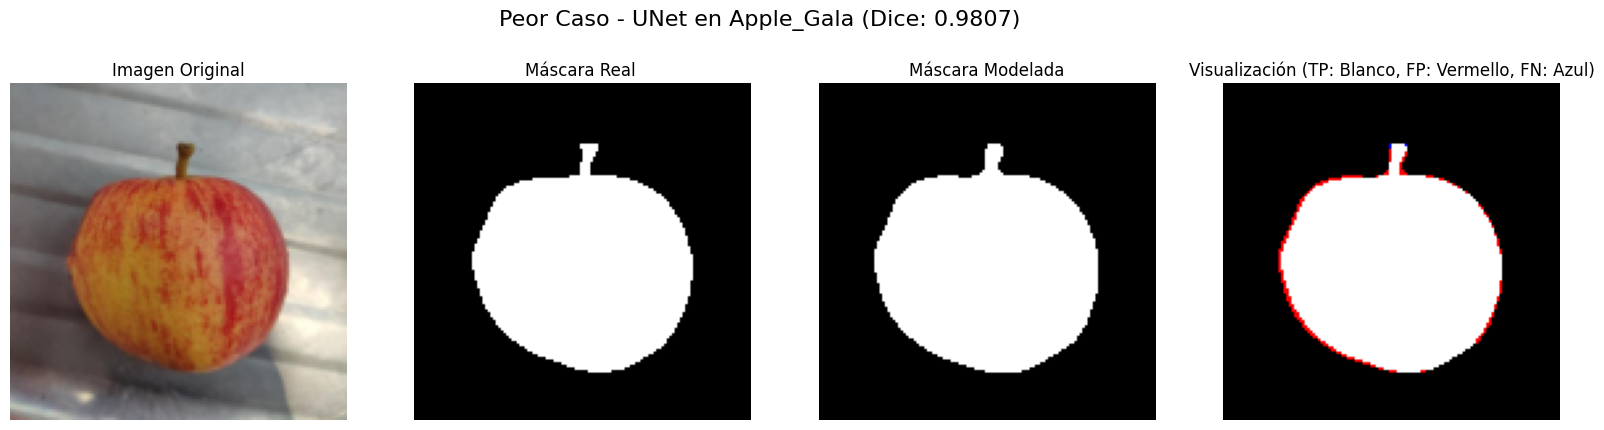


 Entrenando modelo: FCN_ResNet50 
Época 1/30, Pérdida 0.2881, Pérdida Validación: 0.9464
Época 2/30, Pérdida 0.1259, Pérdida Validación: 0.4716
Época 3/30, Pérdida 0.1131, Pérdida Validación: 0.1337
Época 4/30, Pérdida 0.0858, Pérdida Validación: 0.1097
Época 5/30, Pérdida 0.0739, Pérdida Validación: 0.0951
Época 6/30, Pérdida 0.0680, Pérdida Validación: 0.0976
Época 7/30, Pérdida 0.0618, Pérdida Validación: 0.0880
Época 8/30, Pérdida 0.0559, Pérdida Validación: 0.0814
Época 9/30, Pérdida 0.0532, Pérdida Validación: 0.0809
Época 10/30, Pérdida 0.0513, Pérdida Validación: 0.0785
Época 11/30, Pérdida 0.0464, Pérdida Validación: 0.0763
Época 12/30, Pérdida 0.0445, Pérdida Validación: 0.0785
Época 13/30, Pérdida 0.0432, Pérdida Validación: 0.0714
Época 14/30, Pérdida 0.0419, Pérdida Validación: 0.0703
Época 15/30, Pérdida 0.0393, Pérdida Validación: 0.0731
Época 16/30, Pérdida 0.0373, Pérdida Validación: 0.0661
Época 17/30, Pérdida 0.0364, Pérdida Validación: 0.0692
Época 18/30, Pérdida 0

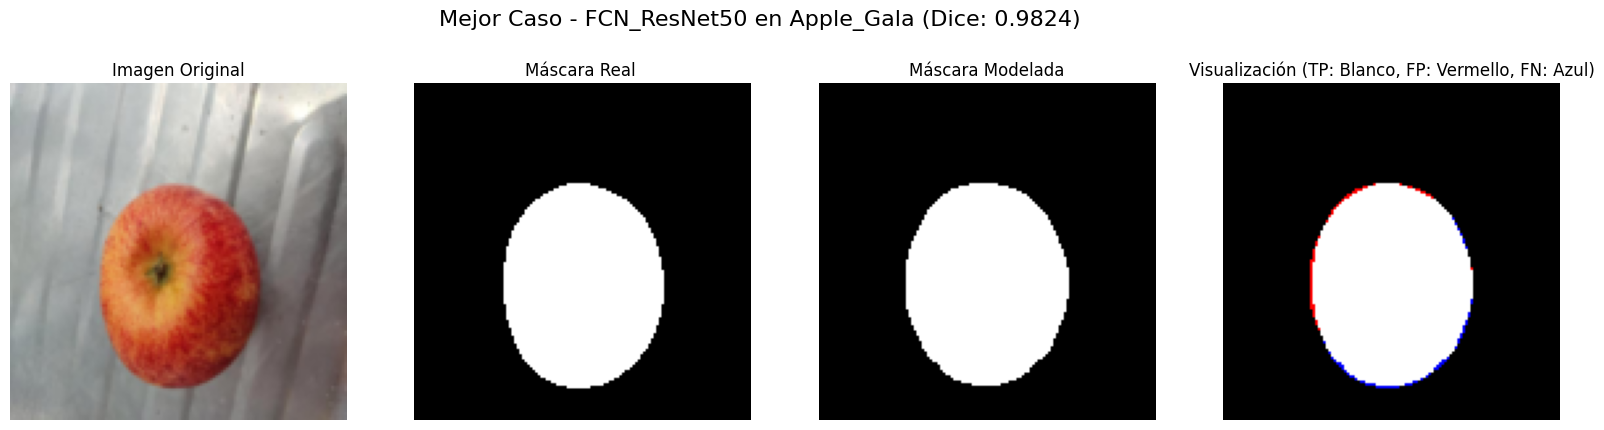


Visualizando peor caso...


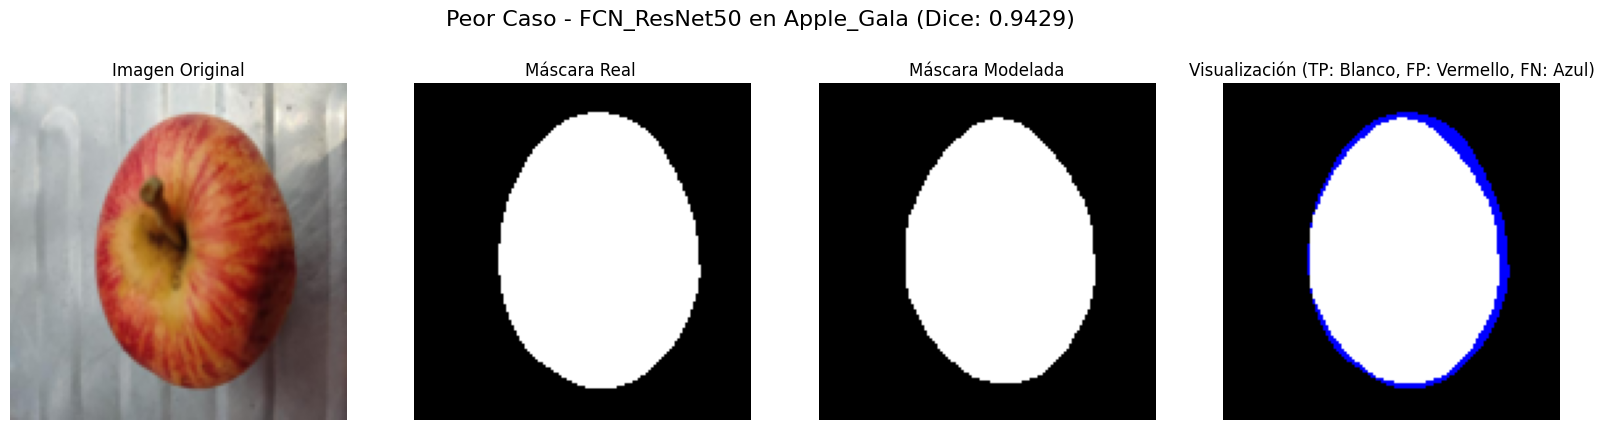


 Entrenando modelo: DeepLabV3_ResNet50 
Época 1/30, Pérdida 0.3513, Pérdida Validación: 0.4856
Época 2/30, Pérdida 0.1647, Pérdida Validación: 0.2724
Época 3/30, Pérdida 0.1310, Pérdida Validación: 0.1747
Época 4/30, Pérdida 0.1130, Pérdida Validación: 0.1321
Época 5/30, Pérdida 0.1026, Pérdida Validación: 0.1209
Época 6/30, Pérdida 0.0962, Pérdida Validación: 0.1148
Época 7/30, Pérdida 0.0890, Pérdida Validación: 0.1119
Época 8/30, Pérdida 0.0825, Pérdida Validación: 0.1035
Época 9/30, Pérdida 0.0791, Pérdida Validación: 0.1014
Época 10/30, Pérdida 0.0741, Pérdida Validación: 0.0957
Época 11/30, Pérdida 0.0721, Pérdida Validación: 0.0930
Época 12/30, Pérdida 0.0689, Pérdida Validación: 0.0923
Época 13/30, Pérdida 0.0679, Pérdida Validación: 0.0893
Época 14/30, Pérdida 0.0645, Pérdida Validación: 0.0874
Época 15/30, Pérdida 0.0625, Pérdida Validación: 0.0836
Época 16/30, Pérdida 0.0605, Pérdida Validación: 0.0811
Época 17/30, Pérdida 0.0575, Pérdida Validación: 0.0794
Época 18/30, Pér

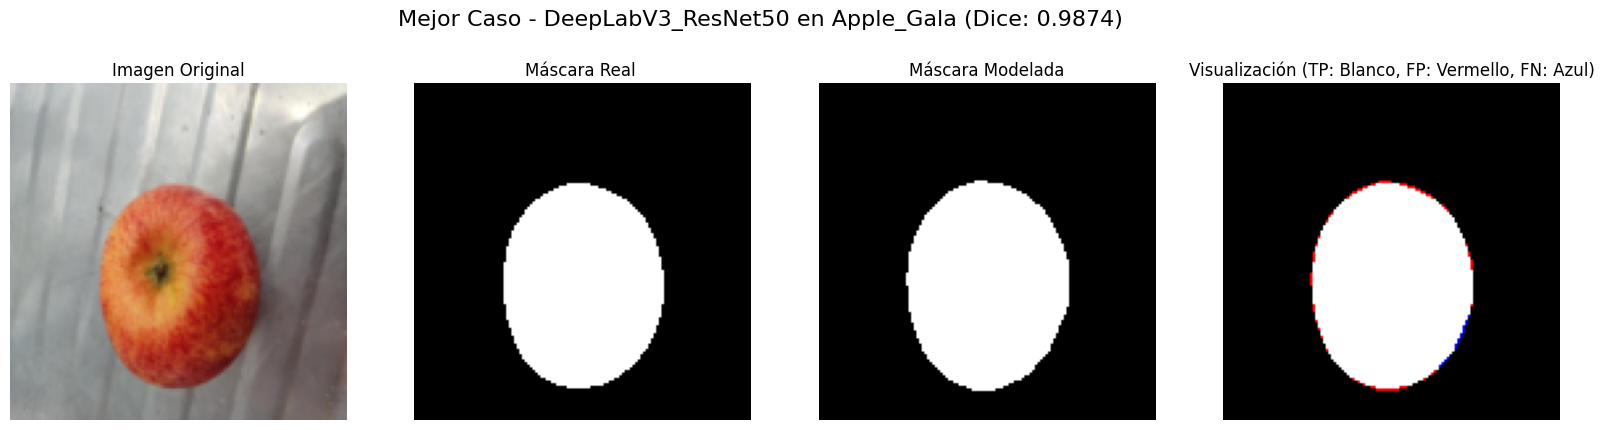


Visualizando peor caso...


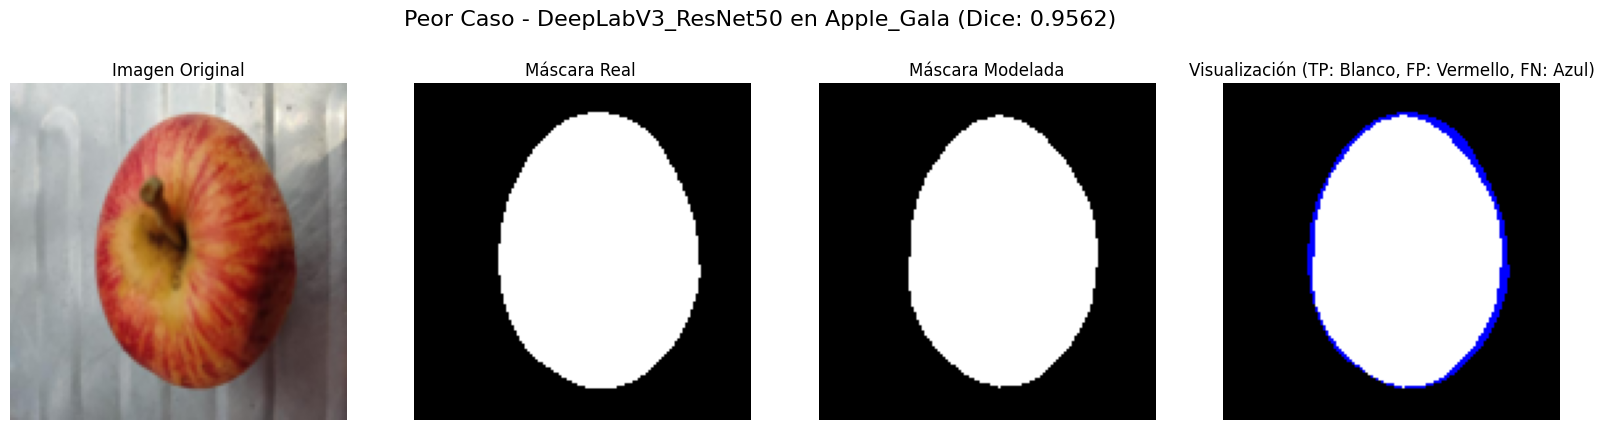

 Adestrando en : Banana 

 Entrenando modelo: UNet 
Época 1/30, Pérdida 0.1078, Pérdida Validación: 0.0558
Época 2/30, Pérdida 0.0679, Pérdida Validación: 0.0679
Época 3/30, Pérdida 0.0636, Pérdida Validación: 0.0555
Época 4/30, Pérdida 0.0595, Pérdida Validación: 0.0548
Época 5/30, Pérdida 0.0548, Pérdida Validación: 0.0520
Época 6/30, Pérdida 0.0525, Pérdida Validación: 0.0485
Época 7/30, Pérdida 0.0535, Pérdida Validación: 0.0470
Época 8/30, Pérdida 0.0520, Pérdida Validación: 0.0467
Época 9/30, Pérdida 0.0500, Pérdida Validación: 0.0498
Época 10/30, Pérdida 0.0497, Pérdida Validación: 0.0483
Época 11/30, Pérdida 0.0505, Pérdida Validación: 0.0522
Época 12/30, Pérdida 0.0475, Pérdida Validación: 0.0430
Época 13/30, Pérdida 0.0461, Pérdida Validación: 0.0411
Época 14/30, Pérdida 0.0529, Pérdida Validación: 0.0440
Época 15/30, Pérdida 0.0533, Pérdida Validación: 0.0637
Época 16/30, Pérdida 0.0494, Pérdida Validación: 0.0418
Época 17/30, Pérdida 0.0449, Pérdida Validación: 0.0413
Época

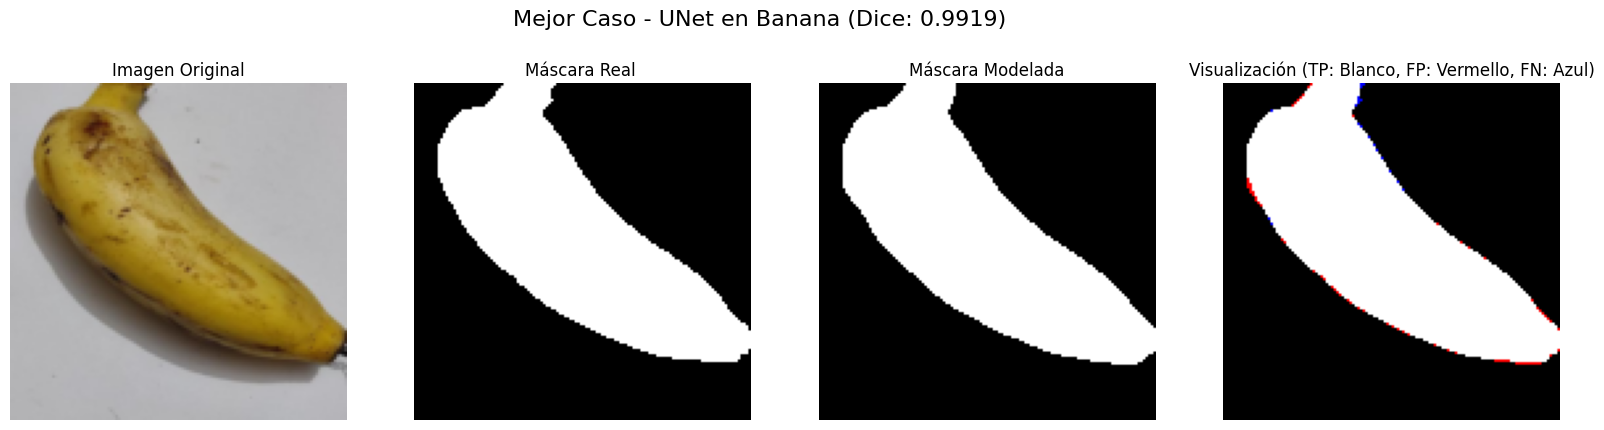


Visualizando peor caso...


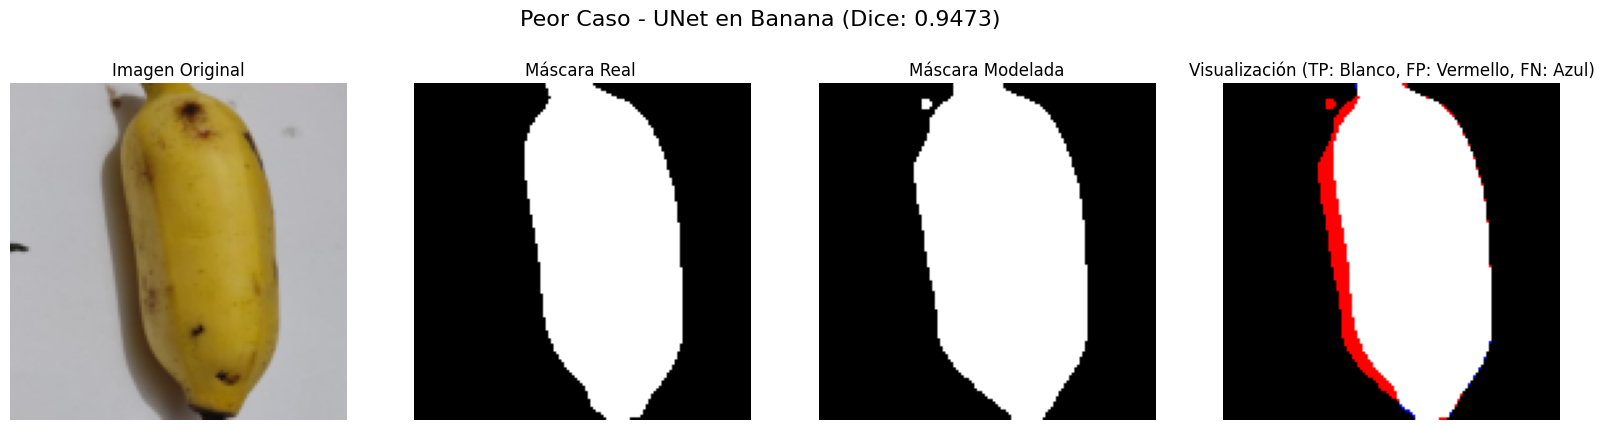


 Entrenando modelo: FCN_ResNet50 
Época 1/30, Pérdida 0.1375, Pérdida Validación: 0.1193
Época 2/30, Pérdida 0.0996, Pérdida Validación: 0.0952
Época 3/30, Pérdida 0.0756, Pérdida Validación: 0.0627
Época 4/30, Pérdida 0.0587, Pérdida Validación: 0.0612
Época 5/30, Pérdida 0.0538, Pérdida Validación: 0.0597
Época 6/30, Pérdida 0.0459, Pérdida Validación: 0.0535
Época 7/30, Pérdida 0.0410, Pérdida Validación: 0.0513
Época 8/30, Pérdida 0.0396, Pérdida Validación: 0.0545
Época 9/30, Pérdida 0.0382, Pérdida Validación: 0.0489
Época 10/30, Pérdida 0.0376, Pérdida Validación: 0.0578
Época 11/30, Pérdida 0.0335, Pérdida Validación: 0.0505
Época 12/30, Pérdida 0.0324, Pérdida Validación: 0.0507
Época 13/30, Pérdida 0.0312, Pérdida Validación: 0.0453
Época 14/30, Pérdida 0.0306, Pérdida Validación: 0.0478
Época 15/30, Pérdida 0.0294, Pérdida Validación: 0.0488
Época 16/30, Pérdida 0.0291, Pérdida Validación: 0.0447
Época 17/30, Pérdida 0.0265, Pérdida Validación: 0.0427
Época 18/30, Pérdida 0

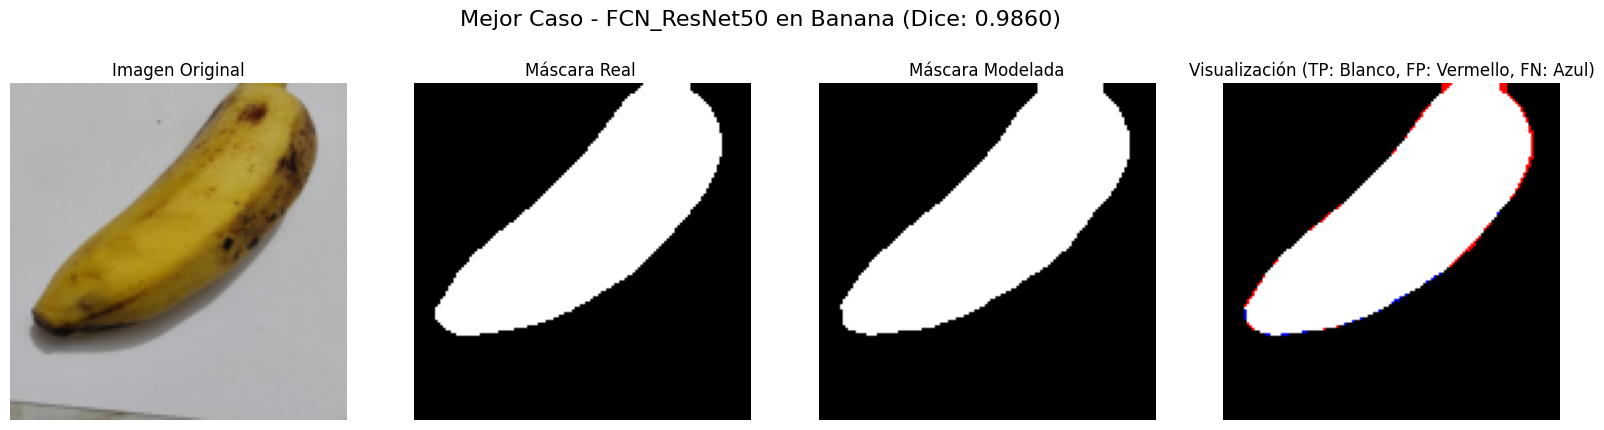


Visualizando peor caso...


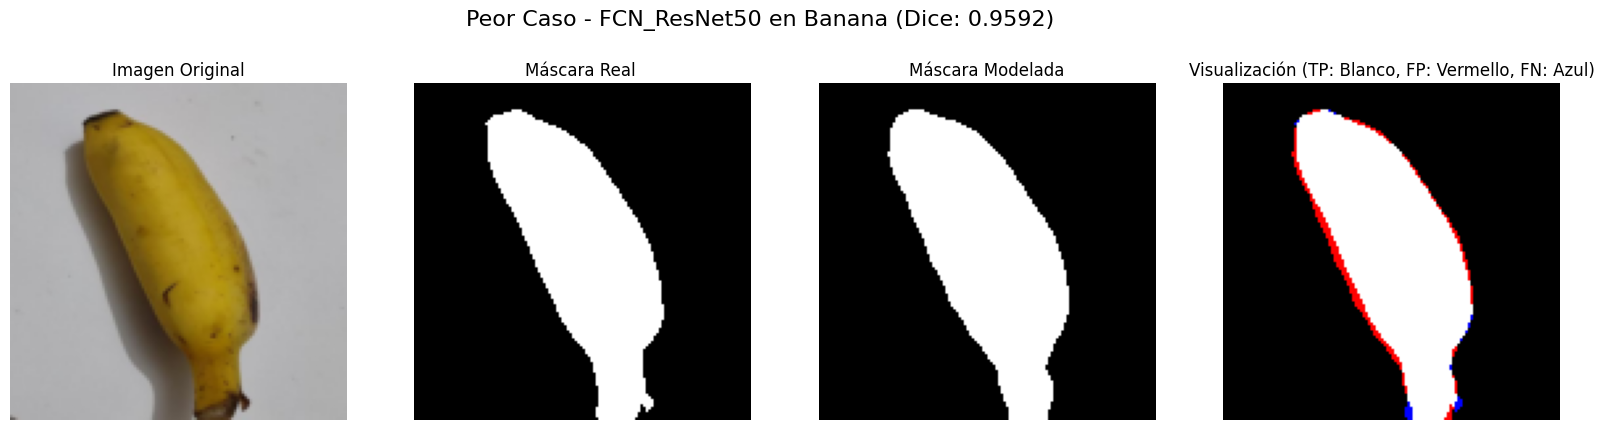


 Entrenando modelo: DeepLabV3_ResNet50 
Época 1/30, Pérdida 0.1208, Pérdida Validación: 0.0906
Época 2/30, Pérdida 0.0927, Pérdida Validación: 0.0824
Época 3/30, Pérdida 0.0763, Pérdida Validación: 0.0707
Época 4/30, Pérdida 0.0636, Pérdida Validación: 0.0640
Época 5/30, Pérdida 0.0560, Pérdida Validación: 0.0604
Época 6/30, Pérdida 0.0525, Pérdida Validación: 0.0616
Época 7/30, Pérdida 0.0470, Pérdida Validación: 0.0559
Época 8/30, Pérdida 0.0453, Pérdida Validación: 0.0533
Época 9/30, Pérdida 0.0415, Pérdida Validación: 0.0558
Época 10/30, Pérdida 0.0412, Pérdida Validación: 0.0586
Época 11/30, Pérdida 0.0391, Pérdida Validación: 0.0510
Época 12/30, Pérdida 0.0373, Pérdida Validación: 0.0540
Época 13/30, Pérdida 0.0363, Pérdida Validación: 0.0542
Época 14/30, Pérdida 0.0351, Pérdida Validación: 0.0496
Época 15/30, Pérdida 0.0355, Pérdida Validación: 0.0479
Época 16/30, Pérdida 0.0336, Pérdida Validación: 0.0462
Época 17/30, Pérdida 0.0318, Pérdida Validación: 0.0469
Época 18/30, Pér

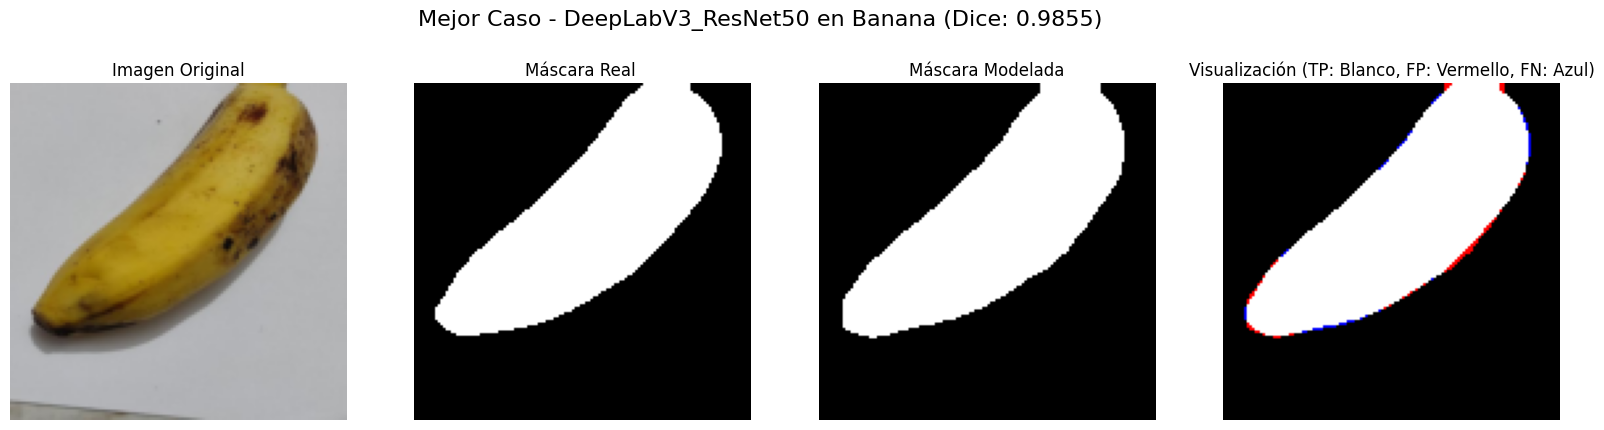


Visualizando peor caso...


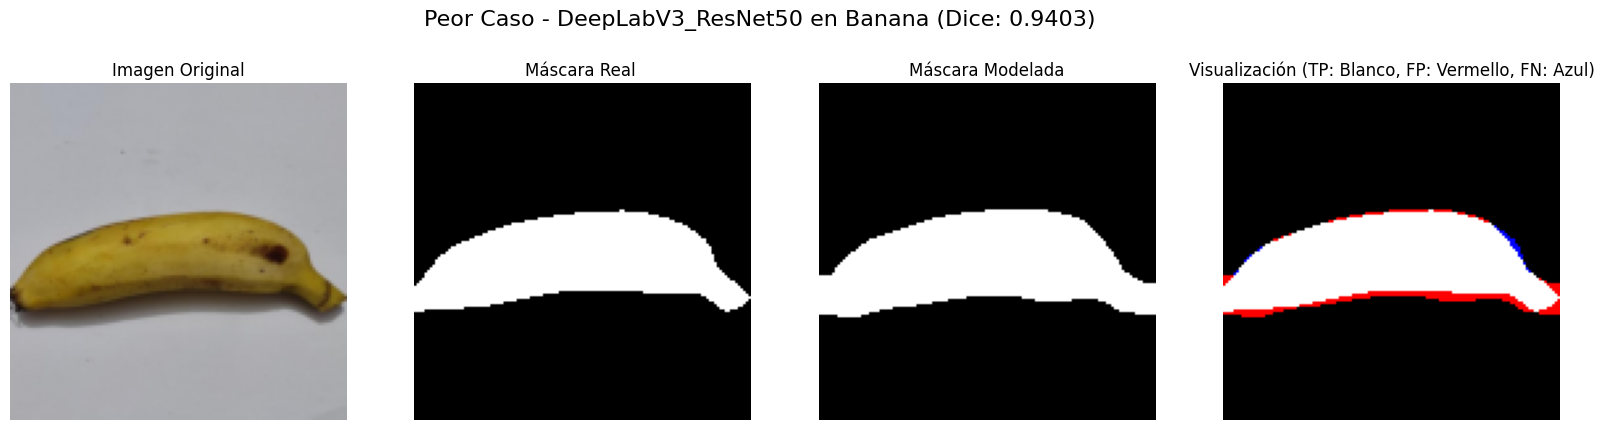

 Adestrando en : Orange 

 Entrenando modelo: UNet 
Época 1/30, Pérdida 0.0521, Pérdida Validación: 0.0466
Época 2/30, Pérdida 0.0466, Pérdida Validación: 0.0500
Época 3/30, Pérdida 0.0460, Pérdida Validación: 0.0466
Época 4/30, Pérdida 0.0442, Pérdida Validación: 0.0437
Época 5/30, Pérdida 0.0427, Pérdida Validación: 0.0424
Época 6/30, Pérdida 0.0416, Pérdida Validación: 0.0437
Época 7/30, Pérdida 0.0414, Pérdida Validación: 0.0437
Época 8/30, Pérdida 0.0419, Pérdida Validación: 0.0427
Época 9/30, Pérdida 0.0415, Pérdida Validación: 0.0435
Época 10/30, Pérdida 0.0410, Pérdida Validación: 0.0434
Early stopping na época 10

Resultados para UNet en Orange:
  - Parámetros: 31.03M
  - Dice promedio (test): 0.9715
  - Hausdorff promedio (test): 13.6600

Visualizando mejor caso...


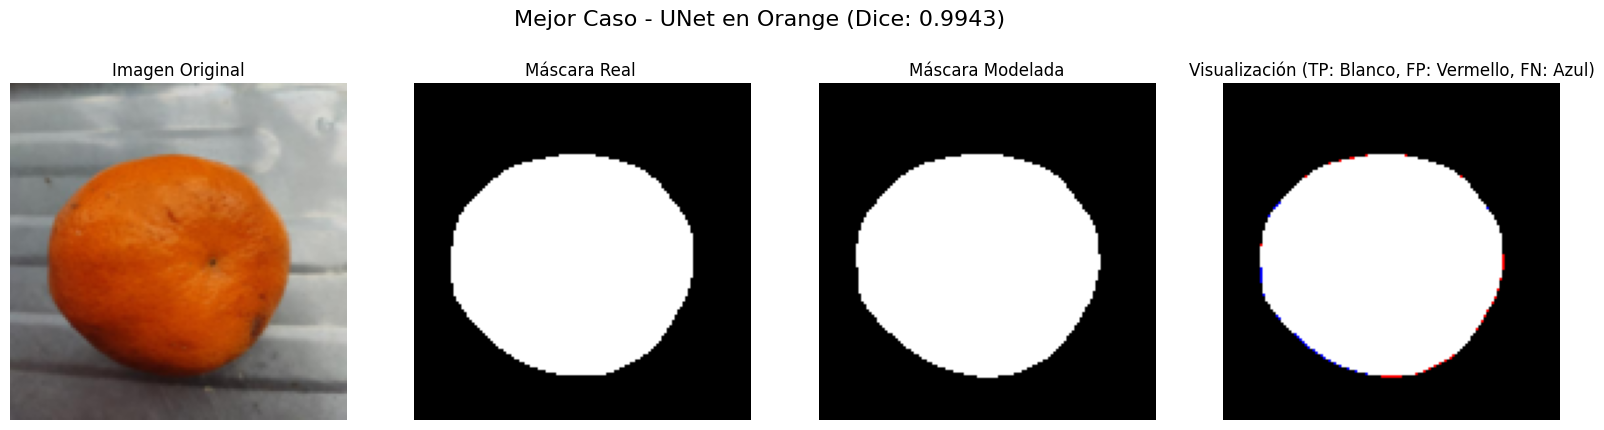


Visualizando peor caso...


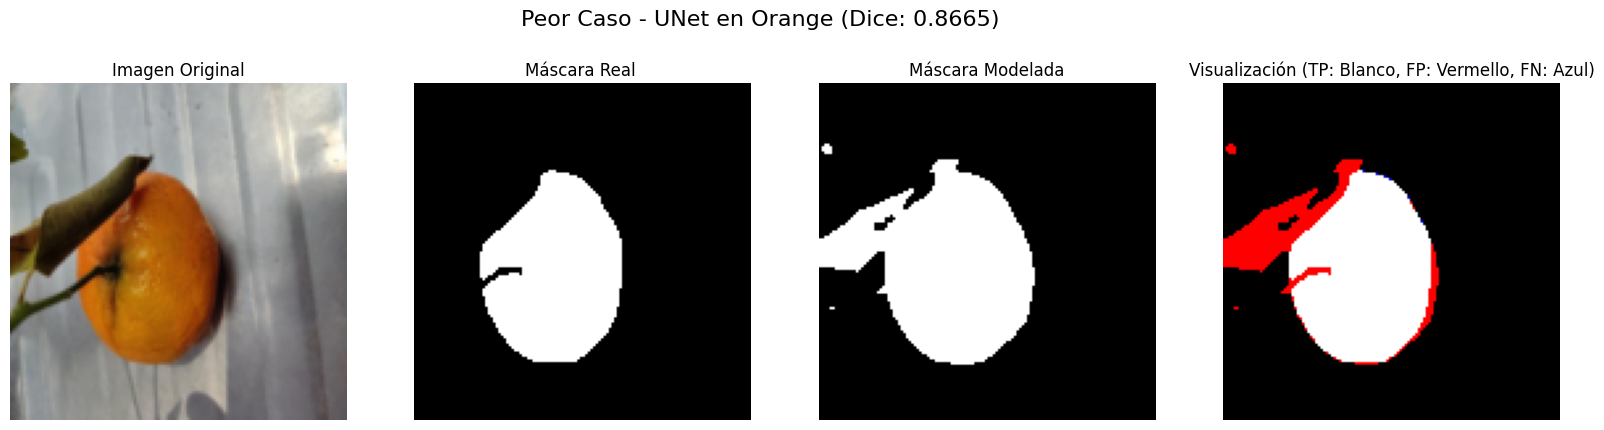


 Entrenando modelo: FCN_ResNet50 
Época 1/30, Pérdida 0.0617, Pérdida Validación: 0.0470
Época 2/30, Pérdida 0.0422, Pérdida Validación: 0.0423
Época 3/30, Pérdida 0.0344, Pérdida Validación: 0.0400
Época 4/30, Pérdida 0.0287, Pérdida Validación: 0.0367
Época 5/30, Pérdida 0.0242, Pérdida Validación: 0.0334
Época 6/30, Pérdida 0.0244, Pérdida Validación: 0.0386
Época 7/30, Pérdida 0.0216, Pérdida Validación: 0.0352
Época 8/30, Pérdida 0.0205, Pérdida Validación: 0.0361
Época 9/30, Pérdida 0.0188, Pérdida Validación: 0.0361
Época 10/30, Pérdida 0.0180, Pérdida Validación: 0.0370
Early stopping na época 10

Resultados para FCN_ResNet50 en Orange:
  - Parámetros: 32.95M
  - Dice promedio (test): 0.9762
  - Hausdorff promedio (test): 8.5505

Visualizando mejor caso...


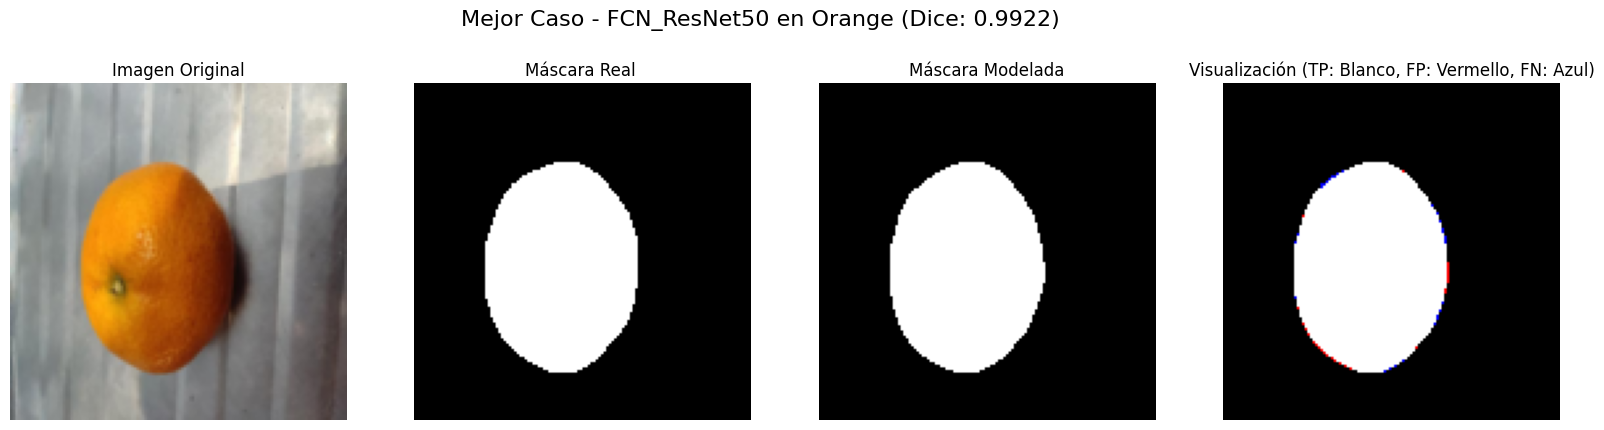


Visualizando peor caso...


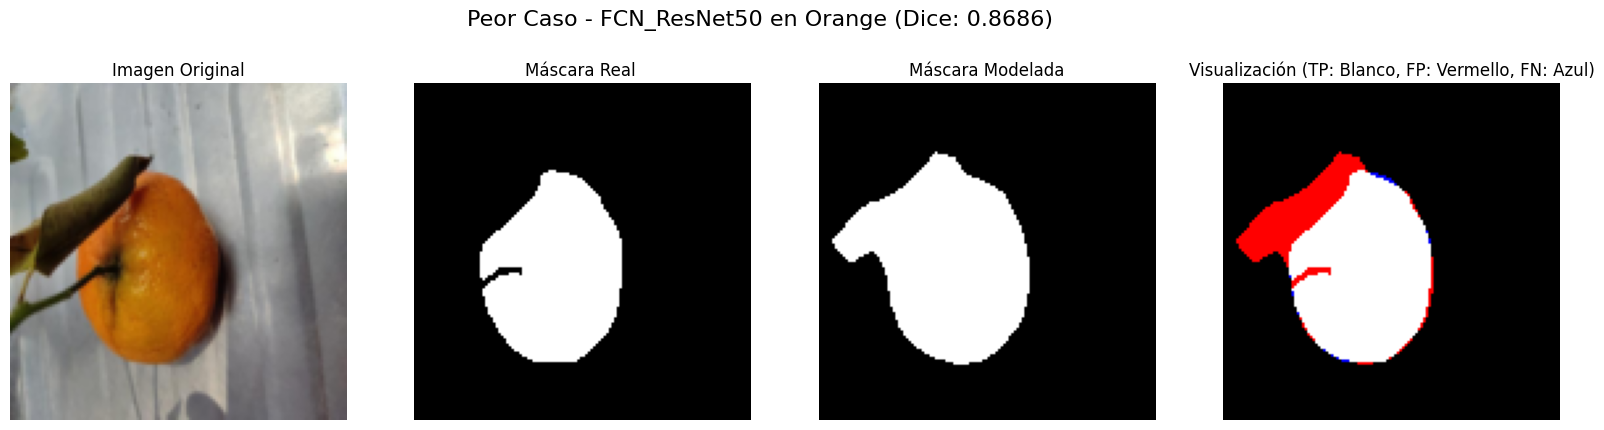


 Entrenando modelo: DeepLabV3_ResNet50 
Época 1/30, Pérdida 0.0632, Pérdida Validación: 0.0497
Época 2/30, Pérdida 0.0472, Pérdida Validación: 0.0498
Época 3/30, Pérdida 0.0388, Pérdida Validación: 0.0413
Época 4/30, Pérdida 0.0329, Pérdida Validación: 0.0398
Época 5/30, Pérdida 0.0296, Pérdida Validación: 0.0399
Época 6/30, Pérdida 0.0268, Pérdida Validación: 0.0423
Época 7/30, Pérdida 0.0265, Pérdida Validación: 0.0409
Época 8/30, Pérdida 0.0264, Pérdida Validación: 0.0422
Época 9/30, Pérdida 0.0254, Pérdida Validación: 0.0384
Época 10/30, Pérdida 0.0239, Pérdida Validación: 0.0392
Época 11/30, Pérdida 0.0238, Pérdida Validación: 0.0428
Época 12/30, Pérdida 0.0234, Pérdida Validación: 0.0400
Época 13/30, Pérdida 0.0229, Pérdida Validación: 0.0403
Época 14/30, Pérdida 0.0224, Pérdida Validación: 0.0401
Early stopping na época 14

Resultados para DeepLabV3_ResNet50 en Orange:
  - Parámetros: 39.63M
  - Dice promedio (test): 0.9776
  - Hausdorff promedio (test): 8.4508

Visualizando me

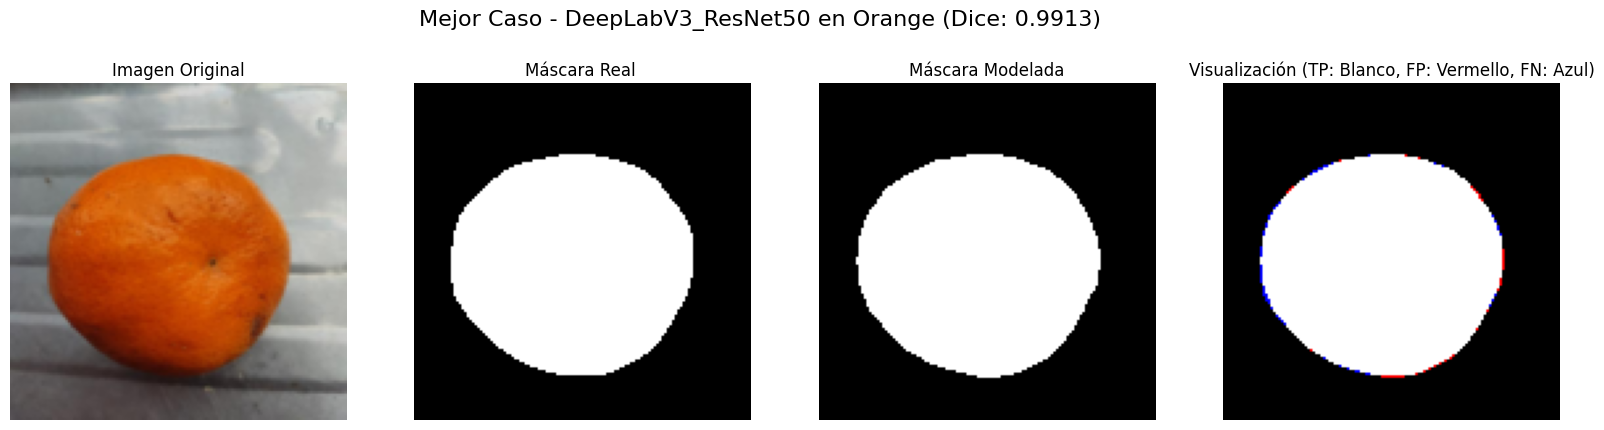


Visualizando peor caso...


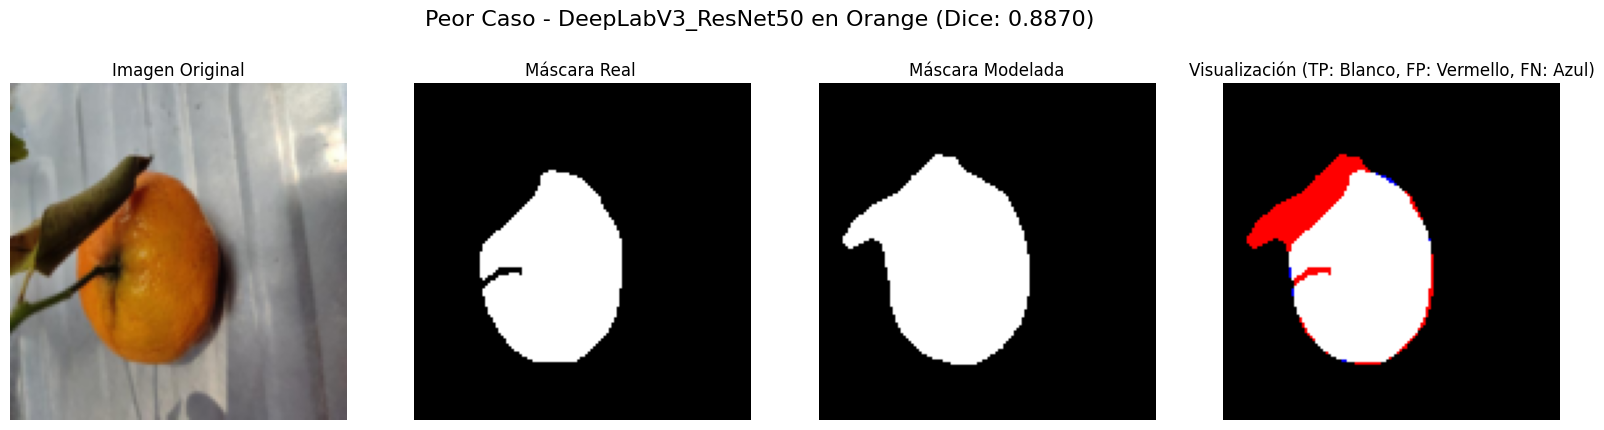

 Adestrando en : Pineapple 

 Entrenando modelo: UNet 
Época 1/30, Pérdida 0.3739, Pérdida Validación: 0.2553
Época 2/30, Pérdida 0.3060, Pérdida Validación: 0.3044
Época 3/30, Pérdida 0.2807, Pérdida Validación: 0.2952
Época 4/30, Pérdida 0.2807, Pérdida Validación: 0.2608
Época 5/30, Pérdida 0.2676, Pérdida Validación: 0.2480
Época 6/30, Pérdida 0.2434, Pérdida Validación: 0.2441
Época 7/30, Pérdida 0.2524, Pérdida Validación: 0.2421
Época 8/30, Pérdida 0.2538, Pérdida Validación: 0.2422
Época 9/30, Pérdida 0.2310, Pérdida Validación: 0.2426
Época 10/30, Pérdida 0.2337, Pérdida Validación: 0.2382
Época 11/30, Pérdida 0.2443, Pérdida Validación: 0.2317
Época 12/30, Pérdida 0.2420, Pérdida Validación: 0.2302
Época 13/30, Pérdida 0.2377, Pérdida Validación: 0.2299
Época 14/30, Pérdida 0.2326, Pérdida Validación: 0.2271
Época 15/30, Pérdida 0.2284, Pérdida Validación: 0.2277
Época 16/30, Pérdida 0.2290, Pérdida Validación: 0.2193
Época 17/30, Pérdida 0.2127, Pérdida Validación: 0.2171
Ép

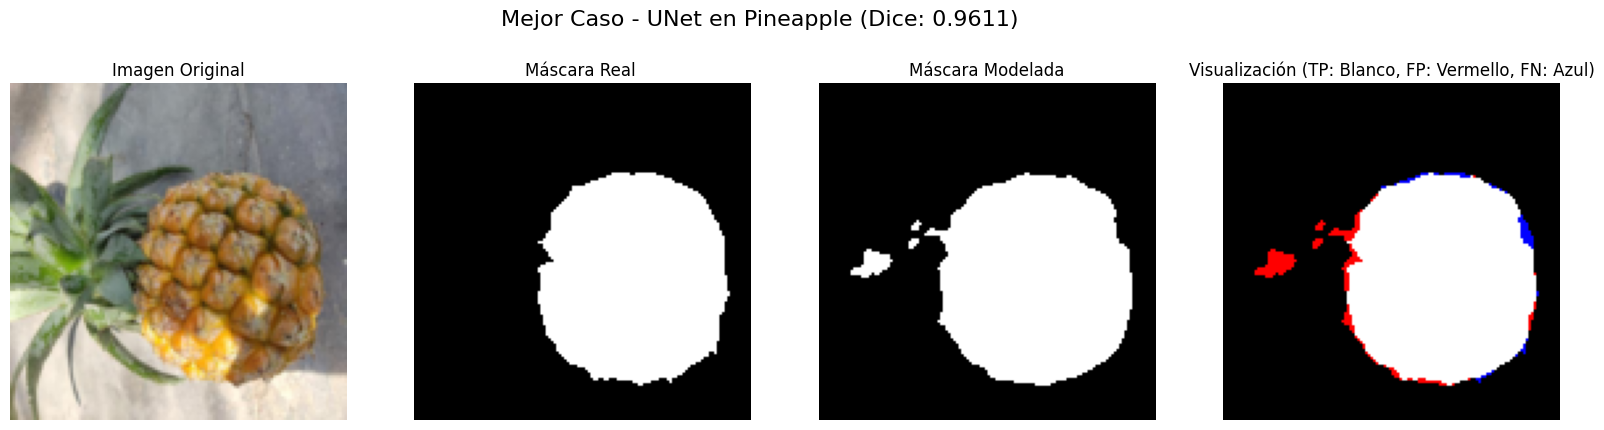


Visualizando peor caso...


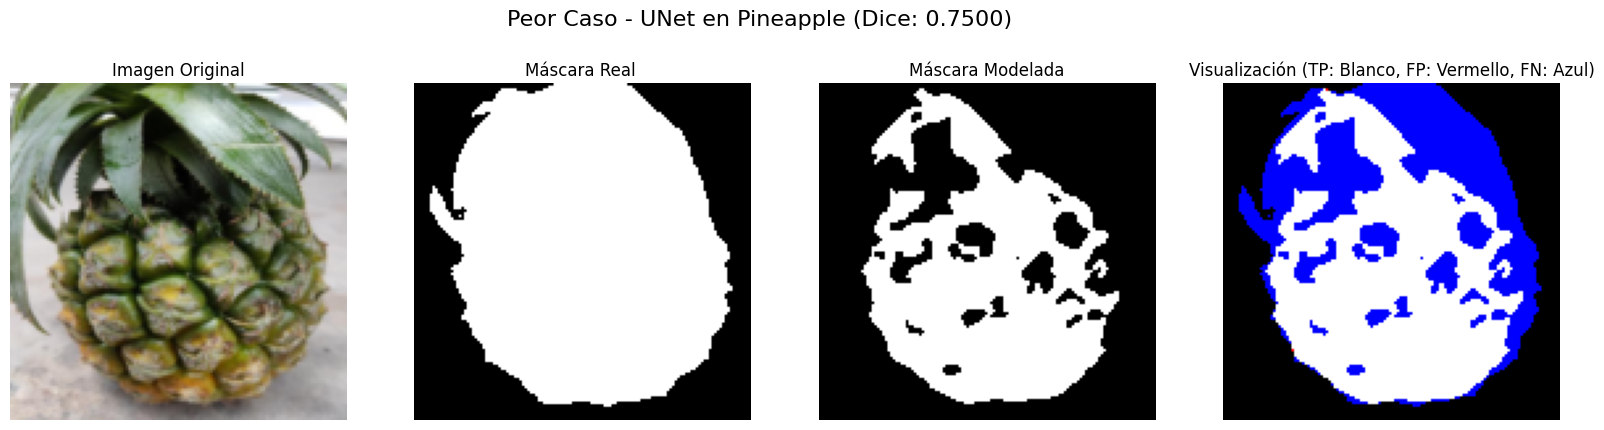


 Entrenando modelo: FCN_ResNet50 
Época 1/30, Pérdida 0.2688, Pérdida Validación: 0.4339
Época 2/30, Pérdida 0.1301, Pérdida Validación: 0.2549
Época 3/30, Pérdida 0.1080, Pérdida Validación: 0.1840
Época 4/30, Pérdida 0.0912, Pérdida Validación: 0.1856
Época 5/30, Pérdida 0.0706, Pérdida Validación: 0.1779
Época 6/30, Pérdida 0.0593, Pérdida Validación: 0.1626
Época 7/30, Pérdida 0.0570, Pérdida Validación: 0.1622
Época 8/30, Pérdida 0.0590, Pérdida Validación: 0.1699
Época 9/30, Pérdida 0.0518, Pérdida Validación: 0.1781
Época 10/30, Pérdida 0.0490, Pérdida Validación: 0.1763
Época 11/30, Pérdida 0.0486, Pérdida Validación: 0.1749
Época 12/30, Pérdida 0.0461, Pérdida Validación: 0.1762
Early stopping na época 12

Resultados para FCN_ResNet50 en Pineapple:
  - Parámetros: 32.95M
  - Dice promedio (test): 0.9364
  - Hausdorff promedio (test): 14.4780

Visualizando mejor caso...


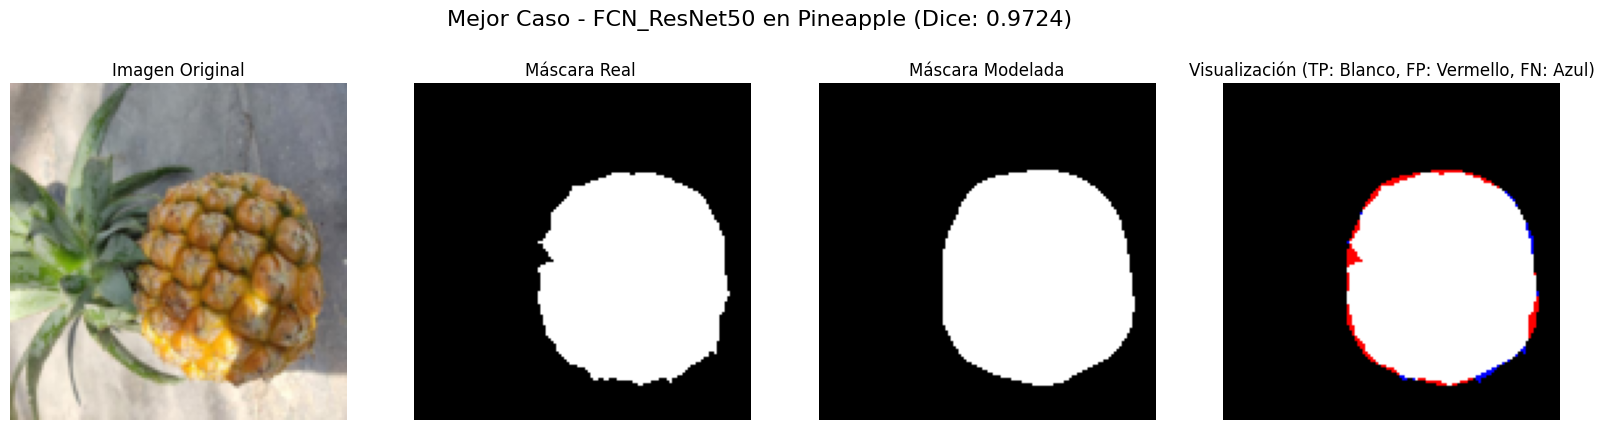


Visualizando peor caso...


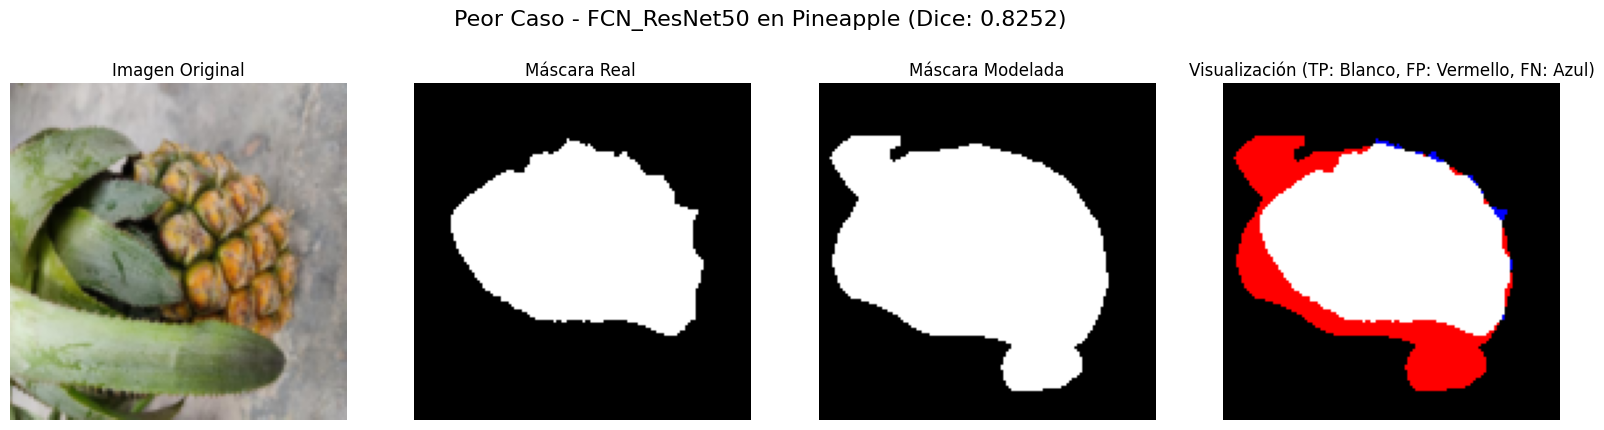


 Entrenando modelo: DeepLabV3_ResNet50 
Época 1/30, Pérdida 0.2718, Pérdida Validación: 0.2120
Época 2/30, Pérdida 0.1516, Pérdida Validación: 0.2104
Época 3/30, Pérdida 0.1084, Pérdida Validación: 0.1805
Época 4/30, Pérdida 0.0920, Pérdida Validación: 0.1672
Época 5/30, Pérdida 0.0758, Pérdida Validación: 0.1726
Época 6/30, Pérdida 0.0645, Pérdida Validación: 0.1847
Época 7/30, Pérdida 0.0591, Pérdida Validación: 0.1812
Época 8/30, Pérdida 0.0562, Pérdida Validación: 0.1767
Época 9/30, Pérdida 0.0509, Pérdida Validación: 0.1801
Early stopping na época 9

Resultados para DeepLabV3_ResNet50 en Pineapple:
  - Parámetros: 39.63M
  - Dice promedio (test): 0.9343
  - Hausdorff promedio (test): 16.4281

Visualizando mejor caso...


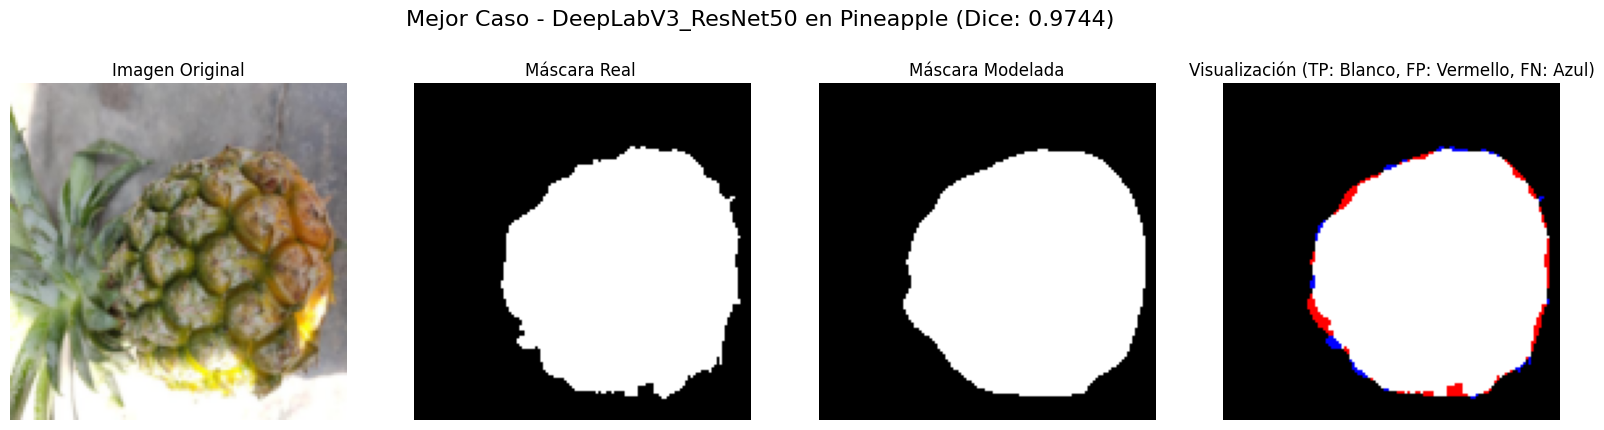


Visualizando peor caso...


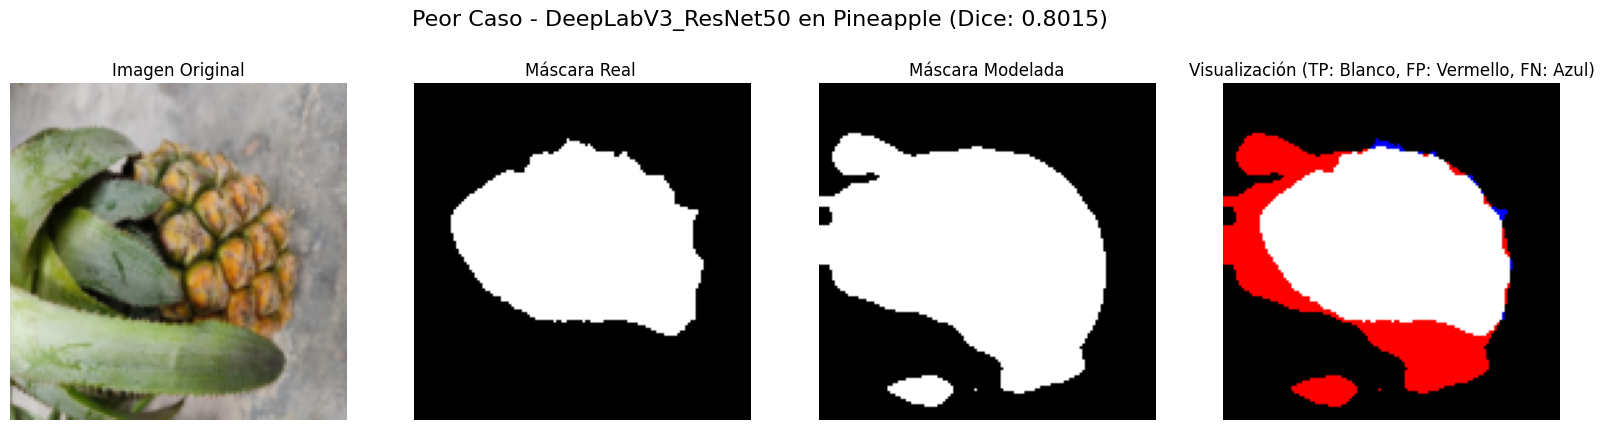

 Adestrando en : Kiwi 

 Entrenando modelo: UNet 
Época 1/30, Pérdida 0.0219, Pérdida Validación: 0.0130
Época 2/30, Pérdida 0.0109, Pérdida Validación: 0.0104
Época 3/30, Pérdida 0.0086, Pérdida Validación: 0.0079
Época 4/30, Pérdida 0.0071, Pérdida Validación: 0.0069
Época 5/30, Pérdida 0.0065, Pérdida Validación: 0.0066
Época 6/30, Pérdida 0.0067, Pérdida Validación: 0.0065
Época 7/30, Pérdida 0.0058, Pérdida Validación: 0.0065
Época 8/30, Pérdida 0.0054, Pérdida Validación: 0.0062
Época 9/30, Pérdida 0.0053, Pérdida Validación: 0.0096
Época 10/30, Pérdida 0.0064, Pérdida Validación: 0.0080
Época 11/30, Pérdida 0.0063, Pérdida Validación: 0.0059
Época 12/30, Pérdida 0.0057, Pérdida Validación: 0.0078
Época 13/30, Pérdida 0.0055, Pérdida Validación: 0.0055
Época 14/30, Pérdida 0.0056, Pérdida Validación: 0.0059
Época 15/30, Pérdida 0.0054, Pérdida Validación: 0.0068
Época 16/30, Pérdida 0.0052, Pérdida Validación: 0.0053
Época 17/30, Pérdida 0.0046, Pérdida Validación: 0.0052
Época 1

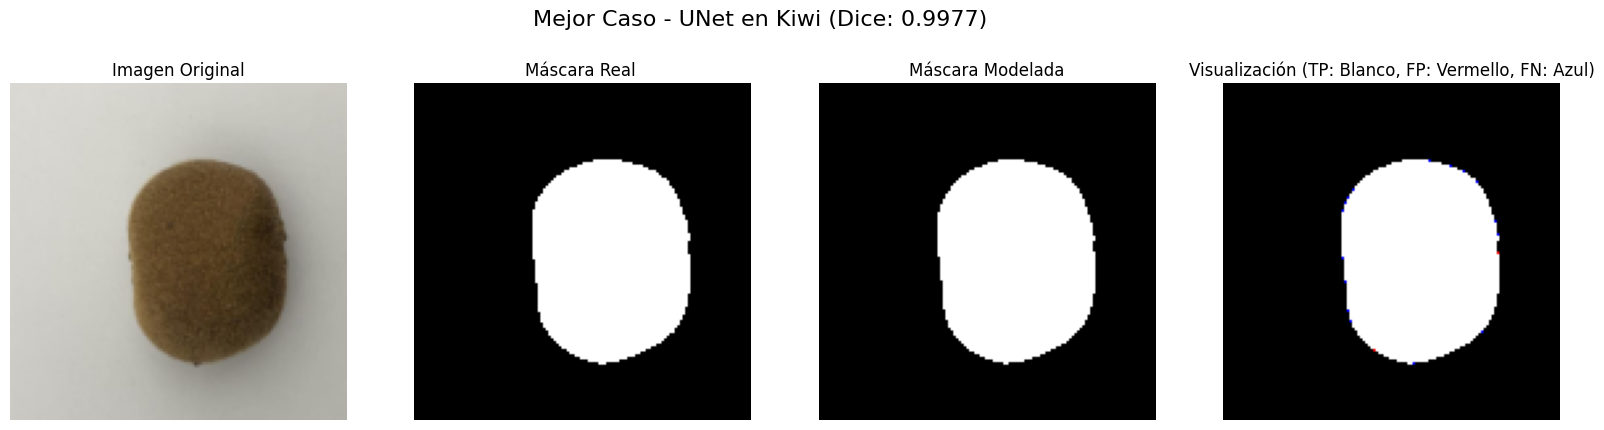


Visualizando peor caso...


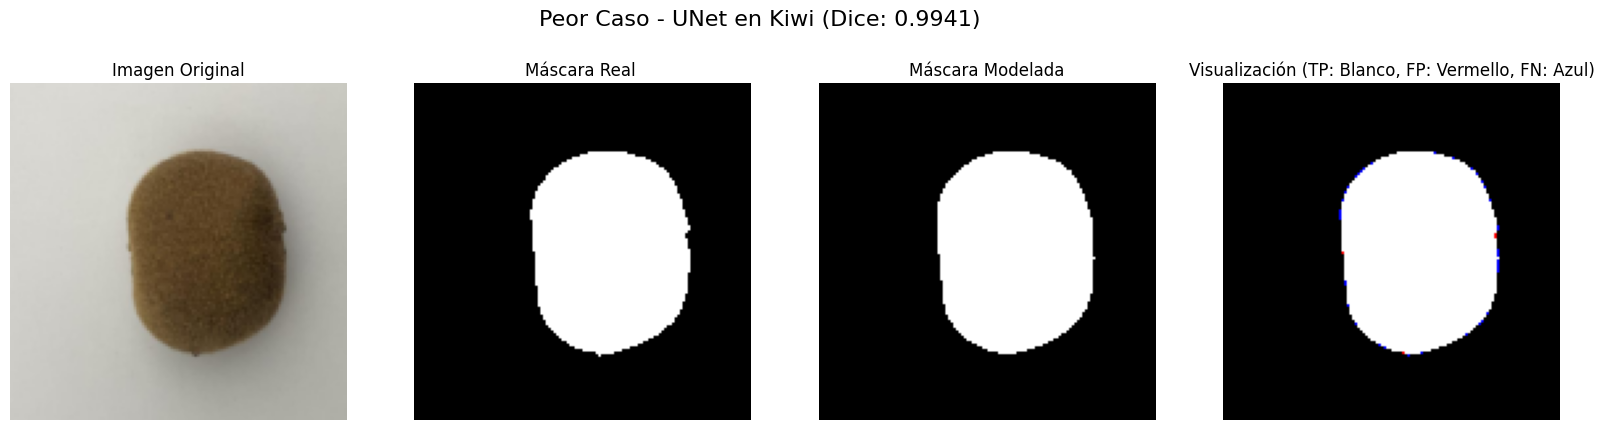


 Entrenando modelo: FCN_ResNet50 
Época 1/30, Pérdida 0.0232, Pérdida Validación: 0.0268
Época 2/30, Pérdida 0.0155, Pérdida Validación: 0.0234
Época 3/30, Pérdida 0.0127, Pérdida Validación: 0.0145
Época 4/30, Pérdida 0.0111, Pérdida Validación: 0.0113
Época 5/30, Pérdida 0.0104, Pérdida Validación: 0.0105
Época 6/30, Pérdida 0.0096, Pérdida Validación: 0.0100
Época 7/30, Pérdida 0.0092, Pérdida Validación: 0.0100
Época 8/30, Pérdida 0.0092, Pérdida Validación: 0.0096
Época 9/30, Pérdida 0.0089, Pérdida Validación: 0.0093
Época 10/30, Pérdida 0.0089, Pérdida Validación: 0.0102
Época 11/30, Pérdida 0.0086, Pérdida Validación: 0.0100
Época 12/30, Pérdida 0.0085, Pérdida Validación: 0.0094
Época 13/30, Pérdida 0.0081, Pérdida Validación: 0.0089
Época 14/30, Pérdida 0.0078, Pérdida Validación: 0.0085
Época 15/30, Pérdida 0.0078, Pérdida Validación: 0.0087
Época 16/30, Pérdida 0.0077, Pérdida Validación: 0.0085
Época 17/30, Pérdida 0.0074, Pérdida Validación: 0.0090
Época 18/30, Pérdida 0

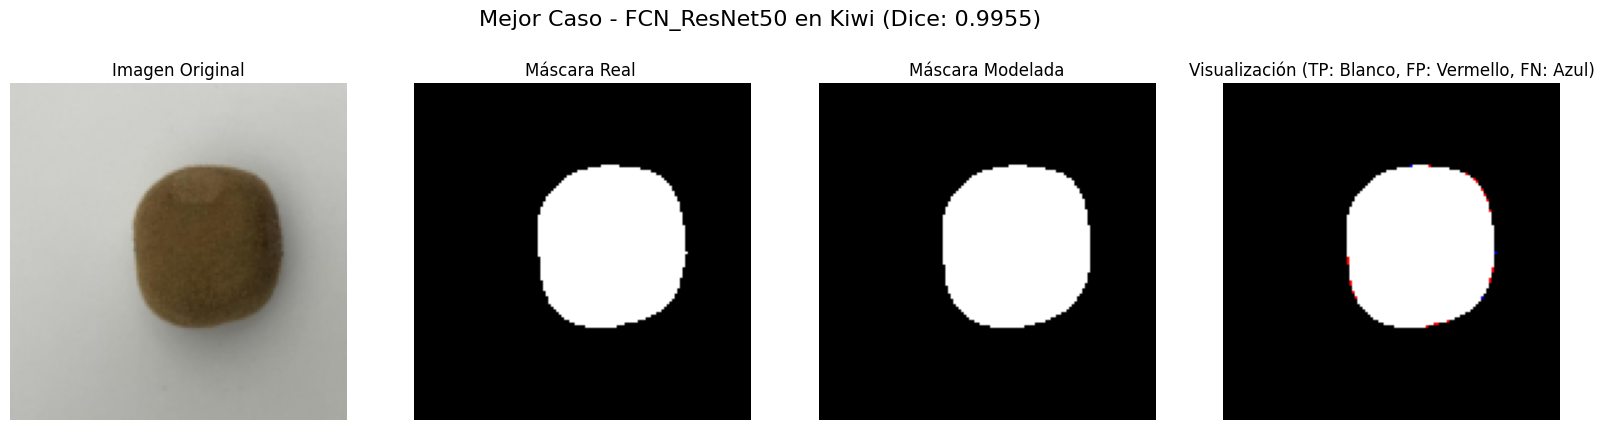


Visualizando peor caso...


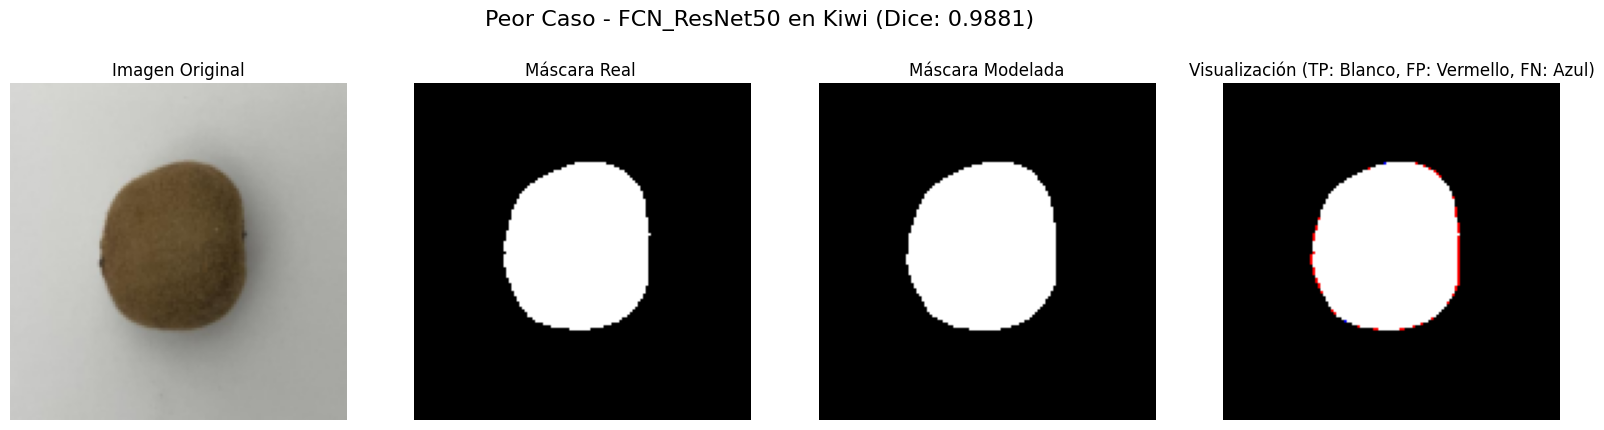


 Entrenando modelo: DeepLabV3_ResNet50 
Época 1/30, Pérdida 0.0275, Pérdida Validación: 0.1094
Época 2/30, Pérdida 0.0202, Pérdida Validación: 0.0416
Época 3/30, Pérdida 0.0183, Pérdida Validación: 0.0201
Época 4/30, Pérdida 0.0170, Pérdida Validación: 0.0159
Época 5/30, Pérdida 0.0161, Pérdida Validación: 0.0152
Época 6/30, Pérdida 0.0154, Pérdida Validación: 0.0148
Época 7/30, Pérdida 0.0152, Pérdida Validación: 0.0150
Época 8/30, Pérdida 0.0145, Pérdida Validación: 0.0144
Época 9/30, Pérdida 0.0140, Pérdida Validación: 0.0139
Época 10/30, Pérdida 0.0137, Pérdida Validación: 0.0134
Época 11/30, Pérdida 0.0134, Pérdida Validación: 0.0136
Época 12/30, Pérdida 0.0131, Pérdida Validación: 0.0129
Época 13/30, Pérdida 0.0128, Pérdida Validación: 0.0127
Época 14/30, Pérdida 0.0125, Pérdida Validación: 0.0125
Época 15/30, Pérdida 0.0122, Pérdida Validación: 0.0119
Época 16/30, Pérdida 0.0120, Pérdida Validación: 0.0123
Época 17/30, Pérdida 0.0121, Pérdida Validación: 0.0120
Época 18/30, Pér

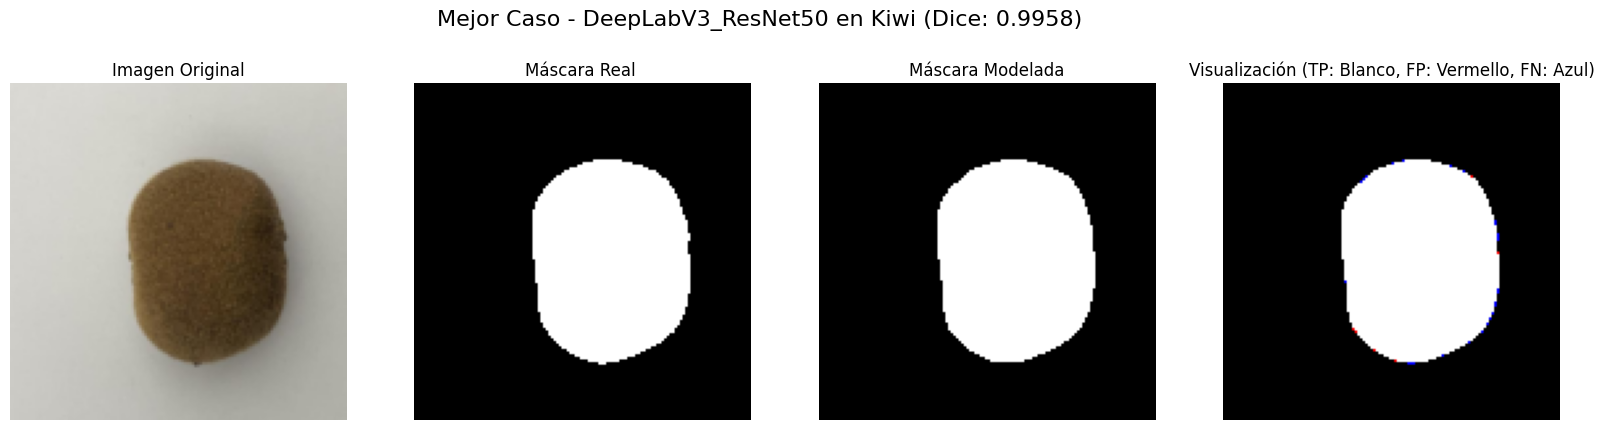


Visualizando peor caso...


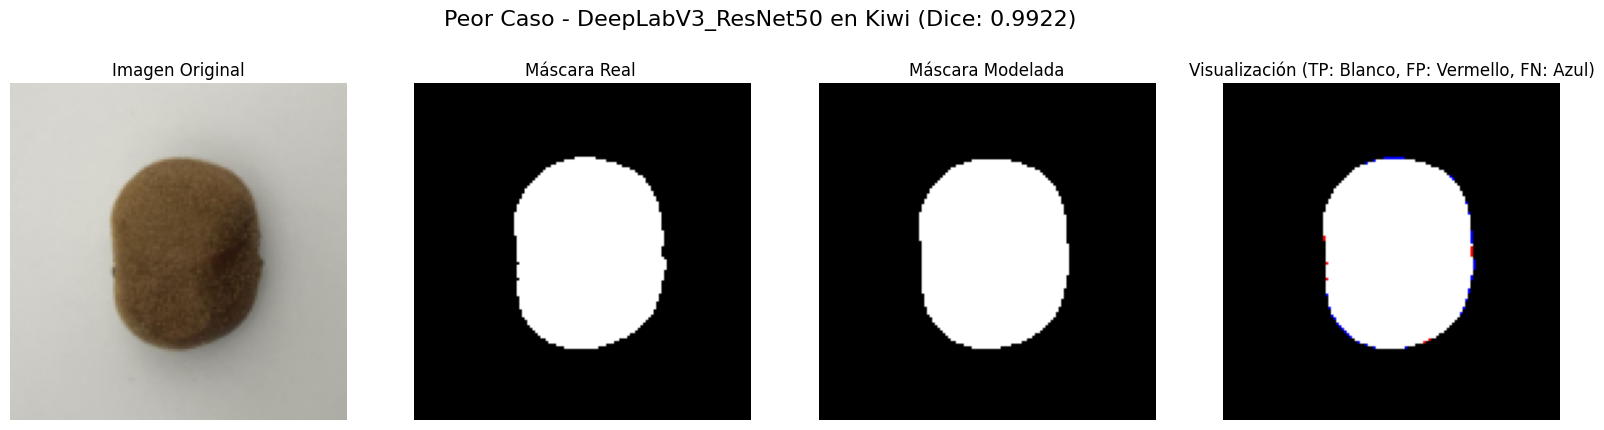

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executando na {device}")

# categorías 
categorias = ['Apple_Gala', 'Banana', 'Orange', 'Pineapple', 'Kiwi']

modelos = {
    "UNet": UNet(in_channels=3, out_channels=1),
    "FCN_ResNet50": fcn_resnet50(weights=None, num_classes=1),
    "DeepLabV3_ResNet50": deeplabv3_resnet50(weights=None, num_classes=1)
}

resultados_train = {}

#  Bucle Principal
for categoria in categorias:
    print(f" Adestrando en : {categoria} ")
    resultados_train[categoria] = {}
    dataloaders = data_dicc[categoria]

    for modelo_nome, modelo in modelos.items():
        print(f"\n Entrenando modelo: {modelo_nome} ")

        # Contar parámetros del modelo
        num_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)


        criterion = nn.BCEWithLogitsLoss() # Da un error raro se utilizo BCELoss
        optimizer = optim.Adam(modelo.parameters(), lr=1e-4)

        # Adestrar
        trained_modelo = adestrar_modelo(modelo, dataloaders, criterion, optimizer, device, num_epocas=30, patience=5)

        # Avaliar
        avg_dice, avg_hausdorff, mellor_caso, peor_caso = avaliar_modelo(trained_modelo, dataloaders['dataloader_test'], device)

        # Gardar resultados
        resultados_train[categoria][modelo_nome] = {
            "params": f"{num_params/1e6:.2f}M",
            "avg_dice": avg_dice,
            "avg_hausdorff": avg_hausdorff
        }

        print(f"\nResultados para {modelo_nome} en {categoria}:")
        print(f"  - Parámetros: {resultados_train[categoria][modelo_nome]['params']}")
        print(f"  - Dice promedio (test): {avg_dice:.4f}")
        print(f"  - Hausdorff promedio (test): {avg_hausdorff:.4f}")

        # Visualizar mellor y peor caso
        print("\nVisualizando mellor caso...")
        resultados(*mellor_caso['data'], titulo=f"Mellor Caso - {modelo_nome} en {categoria} (Dice: {mellor_caso['score']:.4f})")

        print("\nVisualizando peor caso...")
        resultados(*peor_caso['data'], titulo=f"Peor Caso - {modelo_nome} en {categoria} (Dice: {peor_caso['score']:.4f})")

## Xustifica se as predicións se poderían mellorar empregando operacións morfolóxicas de postprocesado.  

Si, poderíamos realizar unha operación de apertura para suavizar os contornos das froitas e unha operación de peche para que non queden ocos (FN) na máscara como no peor caso da piña co modelo UNet.

## Apartado 4


## Que cambios habería que facer na implementación da UNet para aumentar o número de niveis de profundidade?

A implementación da UNet non require ningún cambio no seu código para aumentar os niveis de profundidad do modelo, só fai falta pasar unha lista `features` de maior lonxitude. A implementación proporcionada ten catro niveis, para pasar a 5 executaríamos:
~~~python
UNet_5_niveis = UNet(features=[64, 128, 256, 512, 1024])
~~~
O codificador e o decodificador adáptanse automáticamente e definen unha rede cun nivel adicional de Pull un e Convolución o outro.

## Poderíamos aumentar indefinidamente o número de niveis de profundidade da UNet ou existe algunha limitación?

Non podemos aumnetar a profundidade indefinidamente, existe unha limitación espacial (tamaño da imaxe) pois unha imaxe de 128x128 só pode ter a súa resolución dividida en 2 pola operación de pool unhas 7 veces (128 -> 64 -> 32 -> 16 -> 8 -> 4 -> 2 -> 1). Se definimos 8 niveis provocamos un erro ao intentar reducir un mapa de 1x1.  
Podemos contar tamén cunha restricción á cantidade de niveis co custo computacional, aumentamos significatívamente o número de parámetros e podemos causar que o adestramento do modelo sexa inviable.

## Se aumentamos o tamaño das imaxes de entrada, seguiría funcionando a implementación actual da UNet?

A implementación actual non esixe un tamaño fixo, todas as operacións, convolución e pooling, son locais e aplícanse sen importar o tamaño.